# Proyecto Final — Inteligencia Artificial I
**Universidad Industrial de Santander · Grupo E1 · Periodo 2026-1**  
**Profesora:** Alejandra Moreno  
**Dataset:** Heart Disease UCI  

---
### Integrantes del grupo
- Dexy Lorena Sandoval Merchan — 2215164  
- Wilmer Ferney Gómez Vargas — 2235509  

---
## Contenido
1. Configuración e importaciones  
2. Carga de datos  
3. Análisis Exploratorio de Datos (EDA)  
4. Preprocesamiento  
5. Modelos de Clasificación (GNB, DT, RF, SVM)  
6. Ablation Study — Modelos de Clasificación  
7. Tabla Comparativa Final — Clasificación  
8. Modelo de Regresión  
9. Deep Learning (DNN) — Clasificación cardíaca  
10. Ablation Study — Deep Learning  
11. Aprendizaje No Supervisado (Clustering)  
12. Reducción de Dimensionalidad (PCA / t-SNE)  
13. Tabla Comparativa Final — Todos los modelos  
14. Conclusiones y Próximos Pasos  


## 1. Configuración e Importaciones

In [1]:
# Librerías estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn: preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFE

# Sklearn: modelos de clasificación
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, SVR

# Sklearn: métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc, balanced_accuracy_score,
    silhouette_score, adjusted_rand_score
)

# Sklearn: regresión
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Sklearn: clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster import hierarchy
from scipy.spatial.distance import cdist

# Sklearn: reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Google Colab (comentar si se ejecuta localmente)
# from google.colab import drive
# drive.mount('/content/drive')

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

print('✅ Librerías cargadas correctamente')
print(f'   TensorFlow: {tf.__version__}')


✅ Librerías cargadas correctamente
   TensorFlow: 2.20.0


## 2. Carga de Datos

In [2]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset real desde tu Google Drive
ruta_drive = '/content/drive/MyDrive/Inteligencia Artificial I/heart.csv'

try:
    df = pd.read_csv(ruta_drive)
    print("✓ Dataset cargado correctamente desde Google Drive.")
except FileNotFoundError:
    # Si olvidas montar el drive, usa la URL pública directa para no inventar datos aleatorios
    print("⚠ No se encontró el archivo en Drive. Cargando desde URL pública de respaldo...")
    url_publica = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv'
    df = pd.read_csv(url_publica)

# 2. Estandarizar nombres de columnas si es necesario
kaggle_cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
if list(df.columns) != kaggle_cols:
    df.columns = kaggle_cols[:len(df.columns)]

# 3. EL CORTE DE RAÍZ: Eliminar los duplicados que vienen heredados en el CSV
print(f'Shape inicial en bruto: {df.shape}')
df = df.drop_duplicates()
df.reset_index(drop=True, inplace=True)

print(f'\n✓ Shape final limpio: {df.shape} ({df.shape[0]} filas × {df.shape[1]} columnas)')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head()

⚠ No se encontró el archivo en Drive. Cargando desde URL pública de respaldo...
Shape inicial en bruto: (303, 14)

✓ Shape final limpio: (302, 14) (302 filas × 14 columnas)
Memoria: 33.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Diccionario de variables
diccionario = {
    'age':      'Edad del paciente (años)',
    'sex':      'Sexo (1=Masculino, 0=Femenino)',
    'cp':       'Tipo de dolor de pecho (0-3)',
    'trestbps': 'Presión arterial en reposo (mm Hg)',
    'chol':     'Colesterol sérico (mg/dl)',
    'fbs':      'Glucosa en ayunas >120 mg/dl (1=Sí, 0=No)',
    'restecg':  'Resultados ECG en reposo (0-2)',
    'thalach':  'Frecuencia cardíaca máxima alcanzada',
    'exang':    'Angina inducida por ejercicio (1=Sí, 0=No)',
    'oldpeak':  'Depresión ST inducida por ejercicio',
    'slope':    'Pendiente del segmento ST (0-2)',
    'ca':       'Número de vasos principales coloreados (0-3)',
    'thal':     'Tipo de talasemia (0-3)',
    'target':   'Variable objetivo: Enfermedad cardíaca (1=Sí, 0=No)'
}
pd.DataFrame.from_dict(diccionario, orient='index', columns=['Descripción'])


,Descripción
age,Edad del paciente (años)
sex,"Sexo (1=Masculino, 0=Femenino)"
cp,Tipo de dolor de pecho (0-3)
trestbps,Presión arterial en reposo (mm Hg)
chol,Colesterol sérico (mg/dl)
fbs,"Glucosa en ayunas >120 mg/dl (1=Sí, 0=No)"
restecg,Resultados ECG en reposo (0-2)
thalach,Frecuencia cardíaca máxima alcanzada
exang,"Angina inducida por ejercicio (1=Sí, 0=No)"
oldpeak,Depresión ST inducida por ejercicio


In [4]:
# Resumen estadístico
df.describe().round(2)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00
mean,54.42,0.68,0.96,131.60,246.50,0.15,0.53,149.57,0.33,1.04,1.40,0.72,2.31,0.54
std,9.05,0.47,1.03,17.56,51.75,0.36,0.53,22.90,0.47,1.16,0.62,1.01,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,133.25,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.50,1.00,1.00,130.00,240.50,0.00,1.00,152.50,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.75,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [5]:
# Tipos y valores nulos
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
display(info)
print(f'\n Total valores nulos: {df.isnull().sum().sum()}')


,Tipo,Nulos,% Nulos,Únicos
age,int64,0,0.0,41
sex,int64,0,0.0,2
cp,int64,0,0.0,4
trestbps,int64,0,0.0,49
chol,int64,0,0.0,152
fbs,int64,0,0.0,2
restecg,int64,0,0.0,3
thalach,int64,0,0.0,91
exang,int64,0,0.0,2
oldpeak,float64,0,0.0,40



 Total valores nulos: 0


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Variable Objetivo

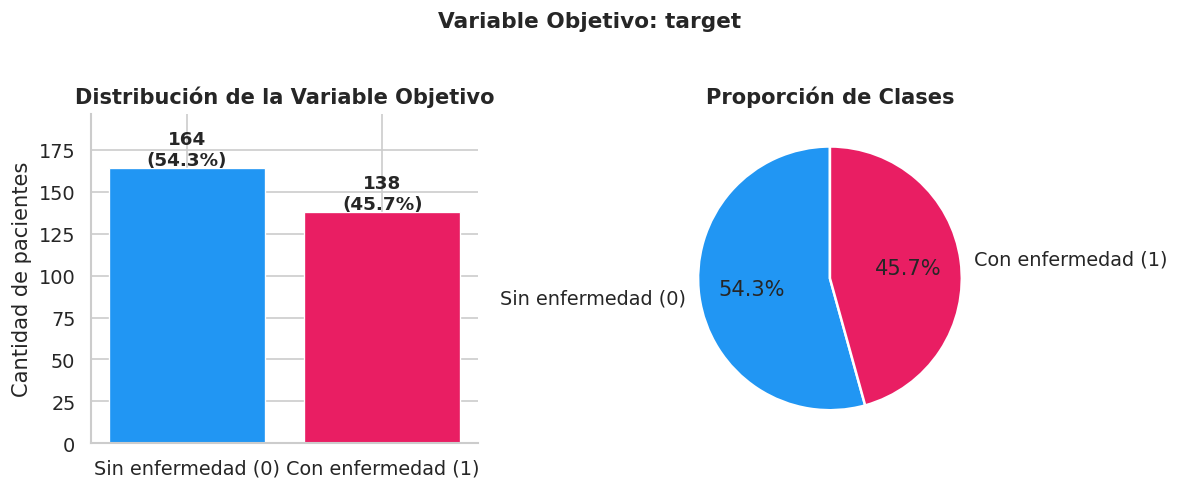


 Balance de clases:
   Clase 0 (Sin enfermedad): 138 (45.7%)
   Clase 1 (Con enfermedad): 164 (54.3%)
   Ratio: 0.84 → Dataset relativamente balanceado


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

conteo = df['target'].value_counts()
etiquetas = ['Sin enfermedad (0)', 'Con enfermedad (1)']

axes[0].bar(etiquetas, conteo.values, color=PALETTE[:2], edgecolor='white', linewidth=0.8)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 2, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de la Variable Objetivo', fontweight='bold')
axes[0].set_ylabel('Cantidad de pacientes')
axes[0].set_ylim(0, conteo.max() * 1.2)

axes[1].pie(conteo.values, labels=etiquetas, autopct='%1.1f%%',
            colors=PALETTE[:2], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción de Clases', fontweight='bold')

plt.suptitle('Variable Objetivo: target', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f'\n Balance de clases:')
print(f'   Clase 0 (Sin enfermedad): {conteo[0]} ({conteo[0]/len(df)*100:.1f}%)')
print(f'   Clase 1 (Con enfermedad): {conteo[1]} ({conteo[1]/len(df)*100:.1f}%)')
print(f'   Ratio: {conteo[0]/conteo[1]:.2f} → Dataset relativamente balanceado')


### 3.2 Variables Numéricas

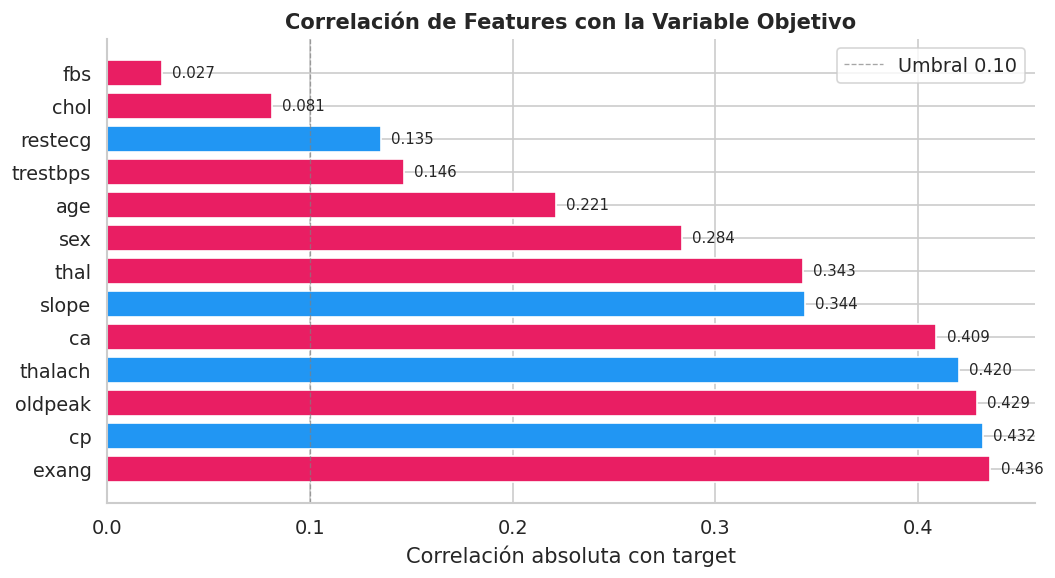

In [7]:
# Correlación con la variable objetivo
correlaciones = df.corr()['target'].drop('target').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colores = ['#2196F3' if c >= 0 else '#E91E63'
           for c in df.corr()['target'].drop('target')[correlaciones.index]]
bars = ax.barh(correlaciones.index, correlaciones.values, color=colores, edgecolor='white')
ax.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Umbral 0.10')
ax.set_xlabel('Correlación absoluta con target')
ax.set_title('Correlación de Features con la Variable Objetivo', fontweight='bold')
ax.legend()
for bar, val in zip(bars, correlaciones.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()


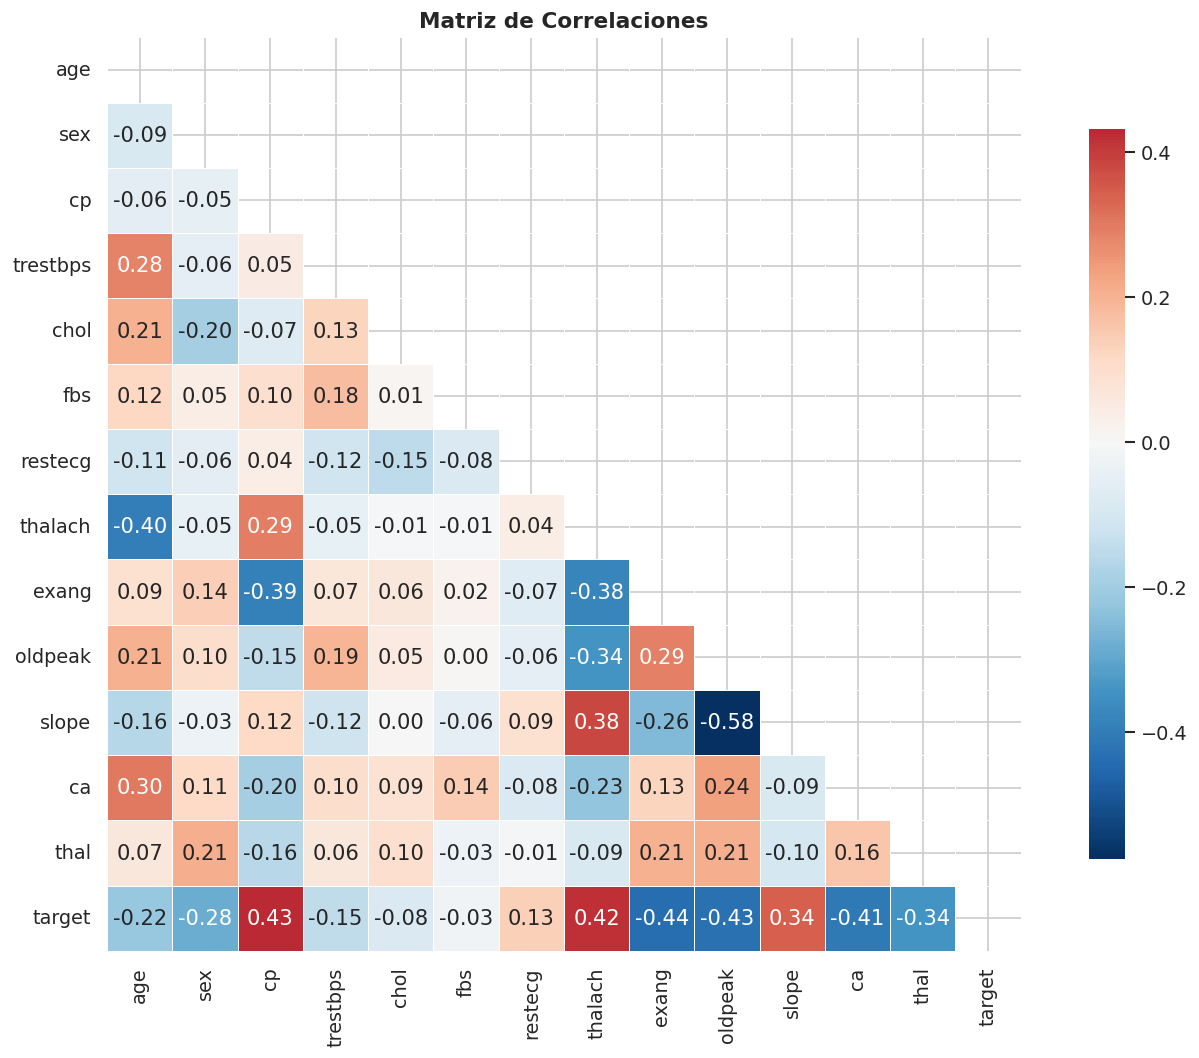

In [8]:
# Mapa de calor de correlaciones
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlaciones', fontweight='bold', fontsize=13)
# plt.savefig('matriz_correlaciones.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()


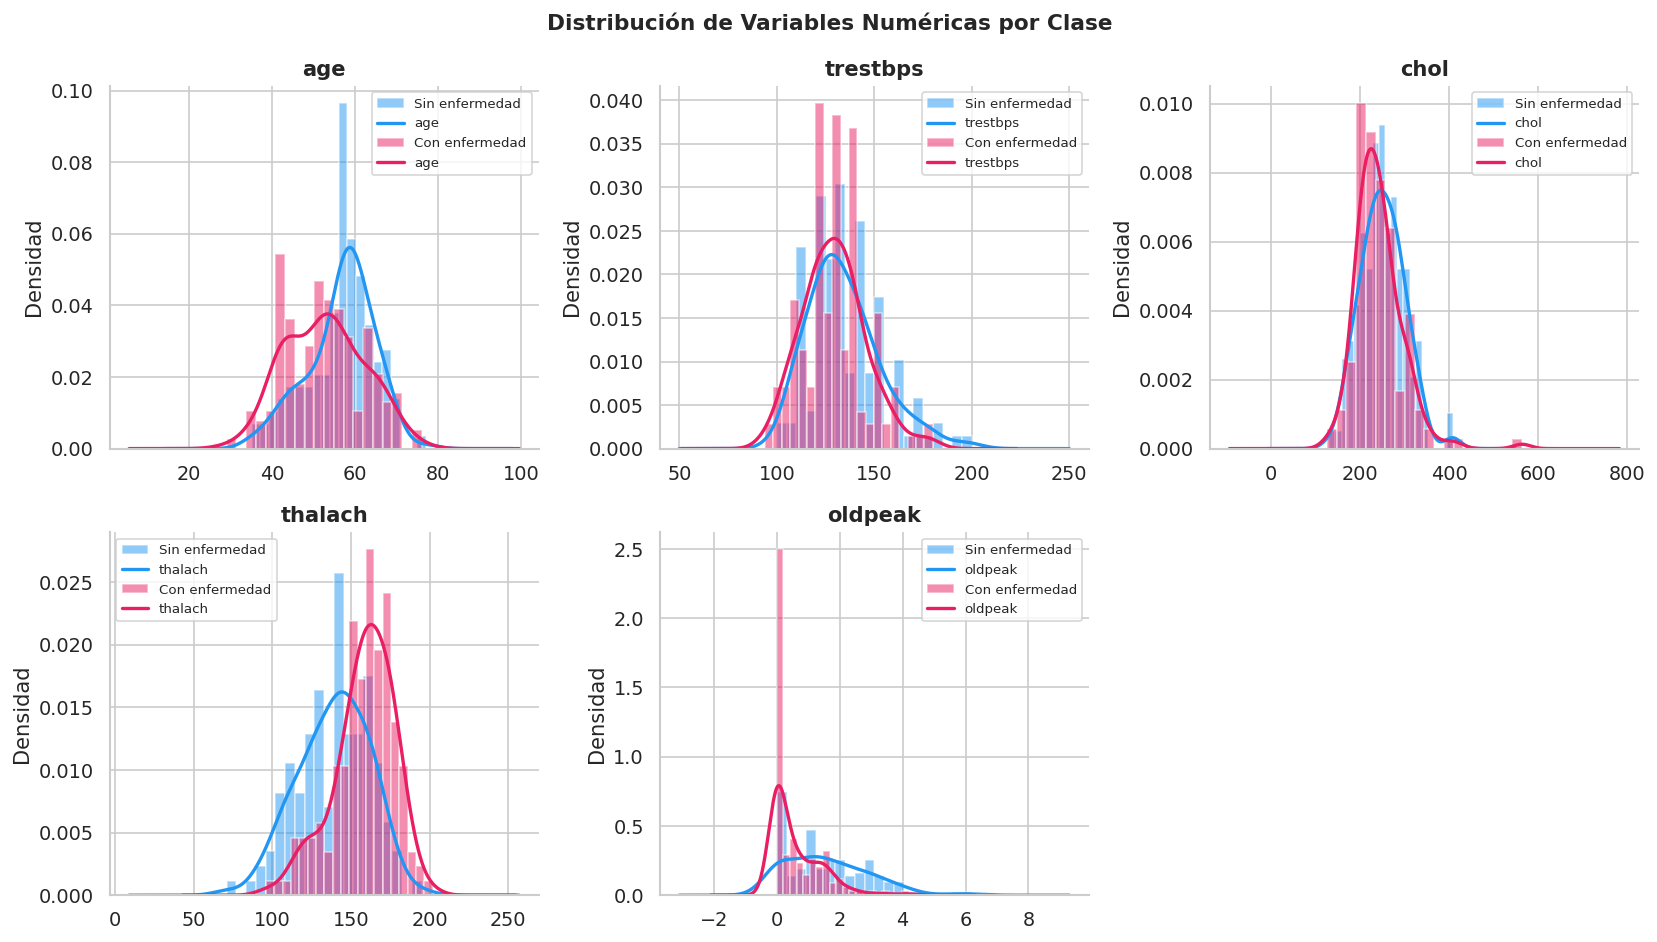


 Estadísticas descriptivas — Variables numéricas continuas:


age              trestbps                  chol                \
         mean median   std     mean median    std    mean median    std   
target                                                                    
0       56.60   58.0  7.96   134.40  130.0  18.73  251.09  249.0  49.45   
1       52.59   52.0  9.51   129.25  130.0  16.20  242.64  234.5  53.46   

       thalach              oldpeak               
          mean median   std    mean median   std  
target                                            
0       139.10  142.0  22.6    1.59    1.4  1.30  
1       158.38  161.0  19.2    0.59    0.2  0.78

In [9]:
# Histogramas + KDE por clase
vars_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(vars_numericas):
    for cls, color, lbl in [(0, PALETTE[0], 'Sin enfermedad'), (1, PALETTE[1], 'Con enfermedad')]:
        subset = df[df['target'] == cls][var]
        axes[i].hist(subset, bins=20, alpha=0.5, color=color,
                     density=True, edgecolor='white', label=lbl)
        subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(var, fontweight='bold')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Distribución de Variables Numéricas por Clase', fontweight='bold', fontsize=13)
# plt.savefig('distribucion_variables_clases.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()

print('\n Estadísticas descriptivas — Variables numéricas continuas:')
stats = df[vars_numericas + ['target']].groupby('target').agg(['mean', 'median', 'std']).round(2)
display(stats)


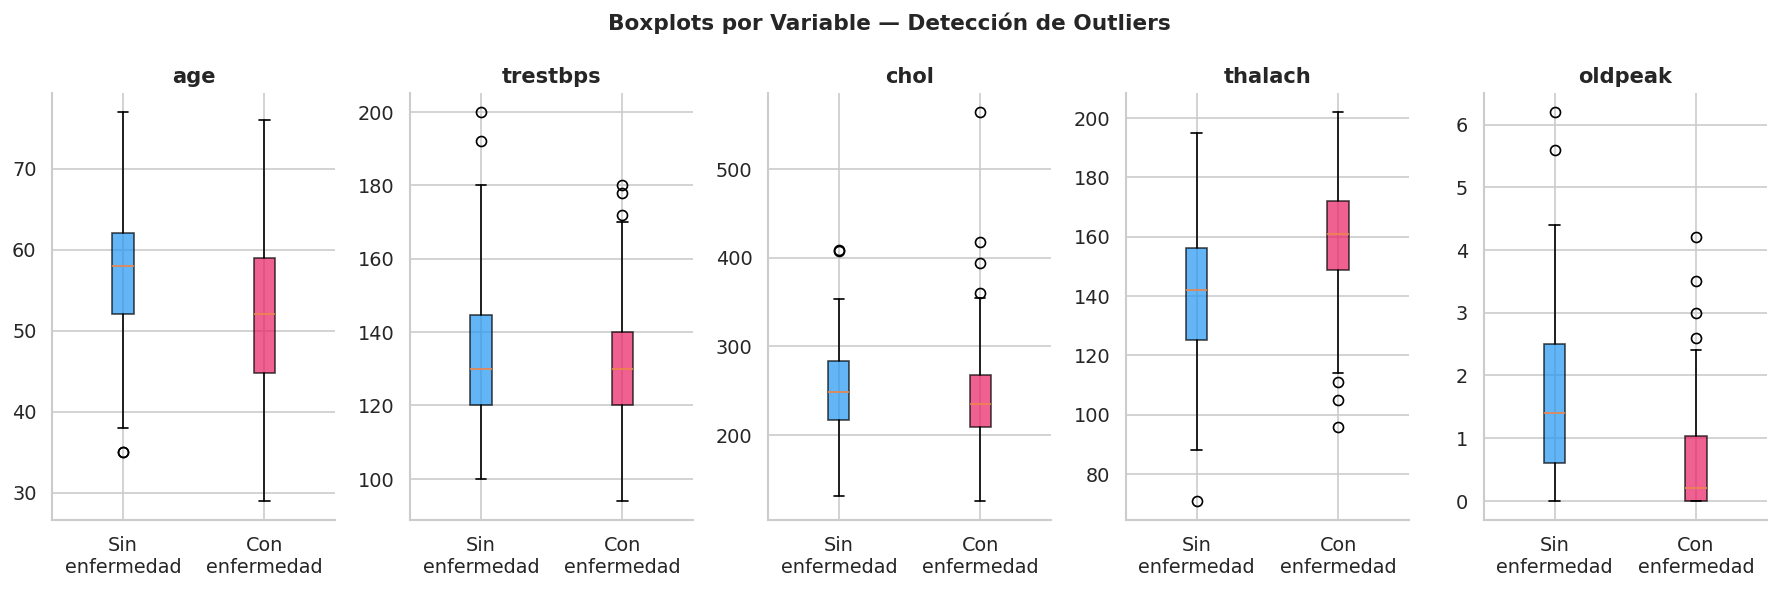

In [10]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(1, len(vars_numericas), figsize=(15, 5))

for i, var in enumerate(vars_numericas):
    data_por_clase = [df[df['target'] == 0][var].values,
                      df[df['target'] == 1][var].values]
    bp = axes[i].boxplot(data_por_clase, patch_artist=True,
                          labels=['Sin\nenfermedad', 'Con\nenfermedad'])
    for patch, color in zip(bp['boxes'], PALETTE[:2]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(var, fontweight='bold')

plt.suptitle('Boxplots por Variable — Detección de Outliers', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


### 3.3 Variables Categóricas

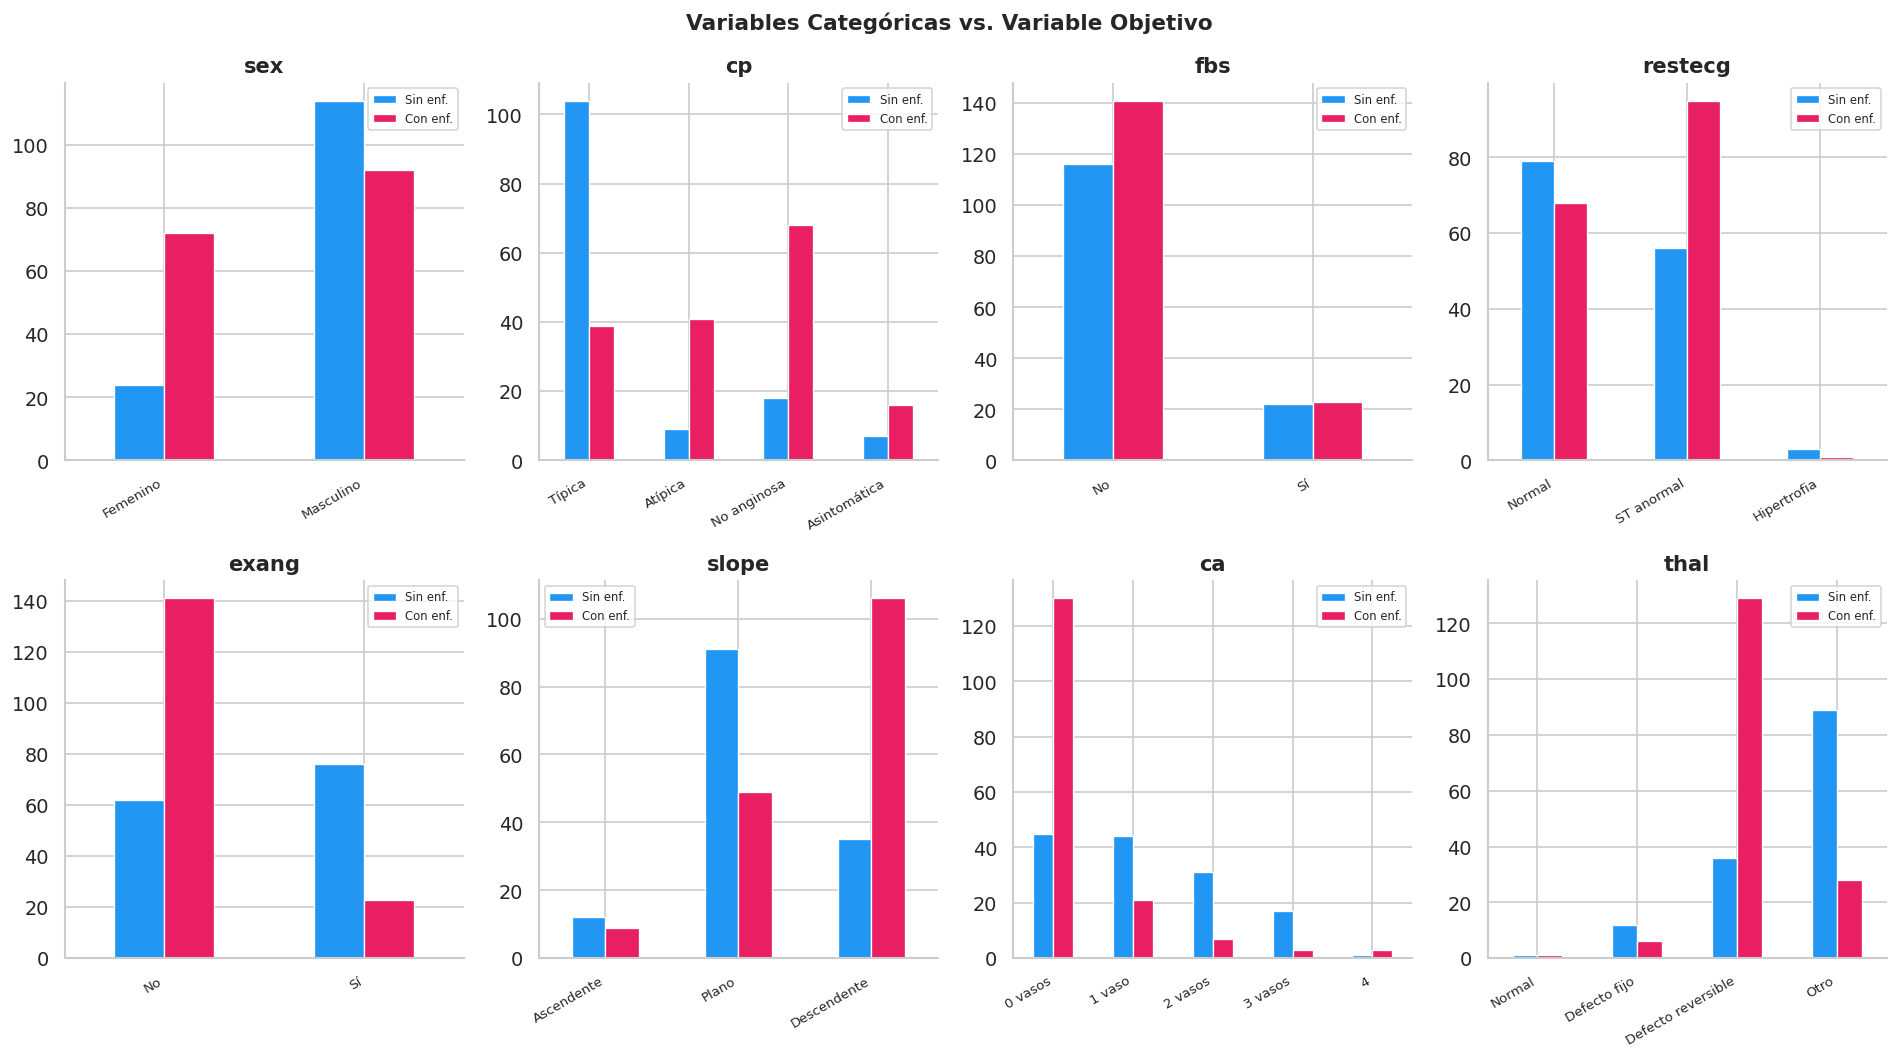

In [11]:
vars_cat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

etiquetas_cat = {
    'sex':     {0: 'Femenino', 1: 'Masculino'},
    'cp':      {0: 'Típica', 1: 'Atípica', 2: 'No anginosa', 3: 'Asintomática'},
    'fbs':     {0: 'No', 1: 'Sí'},
    'restecg': {0: 'Normal', 1: 'ST anormal', 2: 'Hipertrofia'},
    'exang':   {0: 'No', 1: 'Sí'},
    'slope':   {0: 'Ascendente', 1: 'Plano', 2: 'Descendente'},
    'ca':      {0: '0 vasos', 1: '1 vaso', 2: '2 vasos', 3: '3 vasos'},
    'thal':    {0: 'Normal', 1: 'Defecto fijo', 2: 'Defecto reversible', 3: 'Otro'}
}

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(vars_cat):
    tabla = df.groupby([var, 'target']).size().unstack(fill_value=0)
    tabla.plot(kind='bar', ax=axes[i], color=PALETTE[:2], edgecolor='white', linewidth=0.8)
    if var in etiquetas_cat:
        labs = [etiquetas_cat[var].get(x, str(x)) for x in tabla.index]
        axes[i].set_xticklabels(labs, rotation=30, ha='right', fontsize=8)
    else:
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].set_title(var, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(['Sin enf.', 'Con enf.'], fontsize=7)

plt.suptitle('Variables Categóricas vs. Variable Objetivo', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


## 4. Preprocesamiento

### 4.1 Manejo de Valores Nulos

In [12]:
print('\n Verificación de valores nulos:')
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print('   ✅ No se encontraron valores nulos. No se requiere imputación.')
else:
    print(nulos[nulos > 0])
    for col in df.columns[nulos > 0]:
        df[col].fillna(df[col].median(), inplace=True)
    print('   ✅ Imputación con mediana aplicada.')



 Verificación de valores nulos:
   ✅ No se encontraron valores nulos. No se requiere imputación.


### 4.2 Identificación y Tratamiento de Outliers

In [13]:
print('\n Detección de outliers (método IQR):\n')
outlier_info = {}

for var in vars_numericas:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out = ((df[var] < lim_inf) | (df[var] > lim_sup)).sum()
    pct = n_out / len(df) * 100
    outlier_info[var] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                          'Lím. inf': lim_inf, 'Lím. sup': lim_sup,
                          'N outliers': n_out, '% outliers': round(pct, 2)}
    estado = '⚠' if n_out > 0 else '✅'
    print(f'  {estado} {var:12s}: {n_out:3d} outliers ({pct:.1f}%)  [{lim_inf:.1f}, {lim_sup:.1f}]')

display(pd.DataFrame(outlier_info).T.round(2))

print('\n Decisión: Se conservan los outliers porque:')
print('   1. El porcentaje es bajo (< 5% en todas las variables).')
print('   2. Valores extremos en colesterol o presión arterial son clínicamente posibles.')
print('   3. Los modelos a usar (RF, SVM) son relativamente robustos ante outliers.')



 Detección de outliers (método IQR):

  ✅ age         :   0 outliers (0.0%)  [28.5, 80.5]
  ⚠ trestbps    :   9 outliers (3.0%)  [90.0, 170.0]
  ⚠ chol        :   5 outliers (1.7%)  [115.4, 370.4]
  ⚠ thalach     :   1 outliers (0.3%)  [84.1, 215.1]
  ⚠ oldpeak     :   5 outliers (1.7%)  [-2.4, 4.0]


,Q1,Q3,IQR,Lím. inf,Lím. sup,N outliers,% outliers
age,48.00,61.00,13.00,28.50,80.50,0.0,0.00
trestbps,120.00,140.00,20.00,90.00,170.00,9.0,2.98
chol,211.00,274.75,63.75,115.38,370.38,5.0,1.66
thalach,133.25,166.00,32.75,84.12,215.12,1.0,0.33
oldpeak,0.00,1.60,1.60,-2.40,4.00,5.0,1.66



 Decisión: Se conservan los outliers porque:
   1. El porcentaje es bajo (< 5% en todas las variables).
   2. Valores extremos en colesterol o presión arterial son clínicamente posibles.
   3. Los modelos a usar (RF, SVM) son relativamente robustos ante outliers.


### 4.3 Selección de Características (Feature Selection)

 Ranking de características por F-Score (ANOVA):


,Feature,F-Score,p-value
0,exang,70.2552,0.0000
1,cp,68.8643,0.0000
2,oldpeak,67.7219,0.0000
3,thalach,64.2378,0.0000
4,ca,60.2627,0.0000
5,slope,40.2496,0.0000
6,thal,40.0274,0.0000
7,sex,26.2410,0.0000
8,age,15.4745,0.0001
9,trestbps,6.5587,0.0109


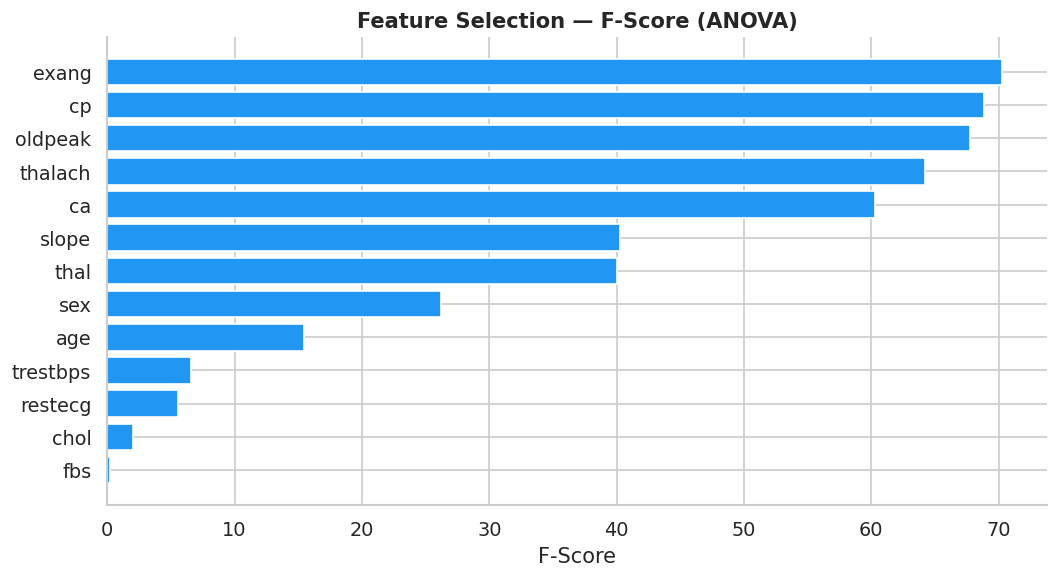


 Features seleccionadas (top 13): ['exang', 'cp', 'oldpeak', 'thalach', 'ca', 'slope', 'thal', 'sex', 'age', 'trestbps', 'restecg', 'chol', 'fbs']


In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

X_all = df.drop('target', axis=1)
y_all = df['target']

# SelectKBest con F-score
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_all, y_all)

scores_df = pd.DataFrame({
    'Feature': X_all.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print(' Ranking de características por F-Score (ANOVA):')
display(scores_df.round(4))

# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(scores_df['Feature'][::-1], scores_df['F-Score'][::-1], color=PALETTE[0], edgecolor='white')
ax.set_xlabel('F-Score')
ax.set_title('Feature Selection — F-Score (ANOVA)', fontweight='bold')
plt.tight_layout(); plt.show()

# Seleccionamos las top 10 características (todas son relevantes en este dataset)
TOP_K = 13
top_features = scores_df['Feature'].iloc[:TOP_K].tolist()
print(f'\n Features seleccionadas (top {TOP_K}): {top_features}')


### 4.4 Separación Features / Target y Split Train-Test

In [15]:
X = df[top_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('\n División del dataset (80% train / 20% test, estratificada):')
print(f'   Train: {X_train.shape[0]} muestras  |  '
      f'Clase 0: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)  '
      f'Clase 1: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'   Test:  {X_test.shape[0]} muestras   |  '
      f'Clase 0: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)  '
      f'Clase 1: {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')



 División del dataset (80% train / 20% test, estratificada):
   Train: 241 muestras  |  Clase 0: 110 (45.6%)  Clase 1: 131 (54.4%)
   Test:  61 muestras   |  Clase 0: 28 (45.9%)  Clase 1: 33 (54.1%)


### 4.5 Normalización (StandardScaler)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\n Estandarización aplicada (media=0, std=1).')
print('   fit_transform → solo en X_train (evita data leakage)')
print('   transform     → aplicado a X_test con los parámetros del train')
print(f'\n   Media X_train_scaled  ≈ {X_train_scaled.mean():.4f}  (debe ser ~0)')
print(f'   Std  X_train_scaled  ≈ {X_train_scaled.std():.4f}  (debe ser ~1)')



 Estandarización aplicada (media=0, std=1).
   fit_transform → solo en X_train (evita data leakage)
   transform     → aplicado a X_test con los parámetros del train

   Media X_train_scaled  ≈ -0.0000  (debe ser ~0)
   Std  X_train_scaled  ≈ 1.0000  (debe ser ~1)


## 5. Modelos de Clasificación

In [17]:
def calcular_metricas(nombre, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
    return {
        'Modelo':         nombre,
        'Accuracy':       round(accuracy_score(y_true, y_pred), 4),
        'Precision':      round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':         round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score':       round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Especificidad':  round(especificidad, 4),
        'Balanced Acc.':  round(balanced_accuracy_score(y_true, y_pred), 4),
    }

def plot_confusion_matrix(y_true, y_pred, nombre, ax):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sin enf. (0)', 'Con enf. (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Conf. Matrix — {nombre}', fontweight='bold', fontsize=10)

def plot_roc(y_true, y_proba, nombre, ax, color):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={roc_auc:.3f})')
    return roc_auc

resultados = []
metricas_nombres = ['Accuracy','Precision','Recall','F1-Score','Especificidad']
print('✅ Funciones auxiliares definidas.')


✅ Funciones auxiliares definidas.


### 5.1 Gaussian Naive Bayes (GNB)

In [18]:
# --- Ejecución de GNB con visualización estilizada ---
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_pred_gnb  = gnb.predict(X_test_scaled)
y_proba_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

met_gnb = calcular_metricas('GNB', y_test, y_pred_gnb)
resultados.append(met_gnb)


df_intermedio = pd.DataFrame([met_gnb]).set_index('Modelo')
display(df_intermedio.style.background_gradient(cmap='YlGn', axis=1).format('{:.4f}'))

print('\n Reporte completo:')
print(classification_report(y_test, y_pred_gnb,
                             target_names=['Sin enfermedad', 'Con enfermedad']))


,Accuracy,Precision,Recall,F1-Score,Especificidad,Balanced Acc.
Modelo,,,,,,
GNB,0.8197,0.7895,0.9091,0.8451,0.7143,0.8117



 Reporte completo:
                precision    recall  f1-score   support

Sin enfermedad       0.87      0.71      0.78        28
Con enfermedad       0.79      0.91      0.85        33

      accuracy                           0.82        61
     macro avg       0.83      0.81      0.81        61
  weighted avg       0.83      0.82      0.82        61



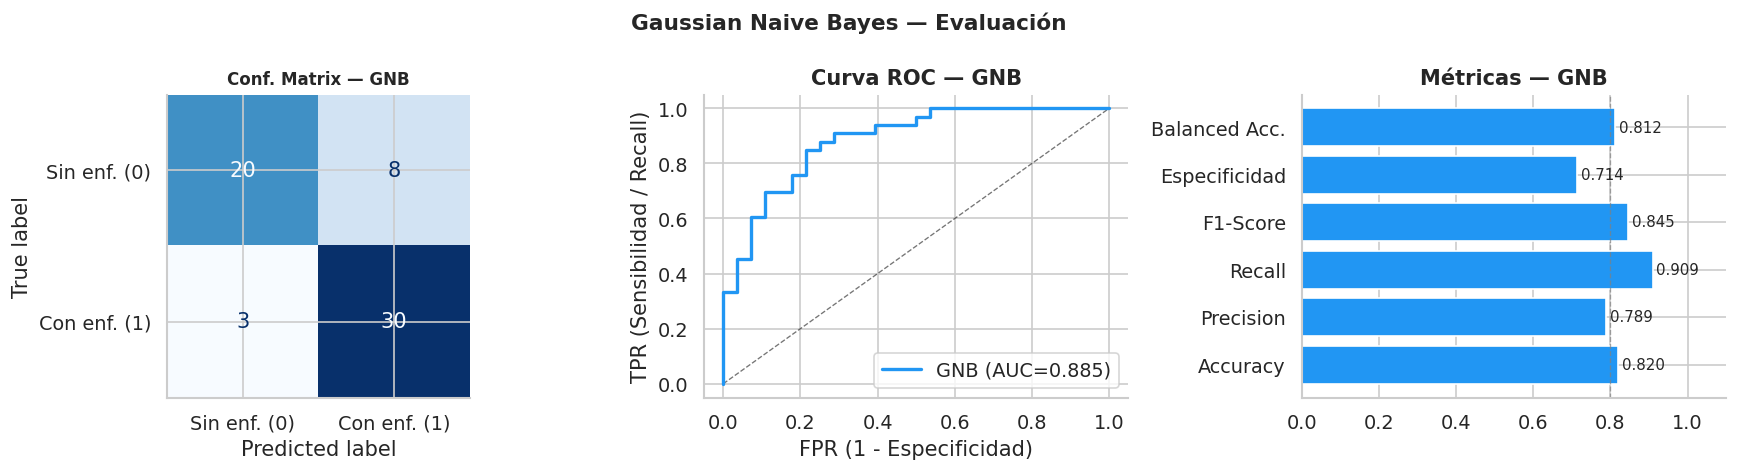

In [19]:
# --- EVALUACIÓN DE GAUSSIAN NAIVE BAYES ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Matriz de Confusión
plot_confusion_matrix(y_test, y_pred_gnb, 'GNB', axes[0])

# 2. Curva ROC
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.6)
plot_roc(y_test, y_proba_gnb, 'GNB', axes[1], PALETTE[0])
axes[1].set_xlabel('FPR (1 - Especificidad)')
axes[1].set_ylabel('TPR (Sensibilidad / Recall)')
axes[1].set_title('Curva ROC — GNB', fontweight='bold')
axes[1].legend()

# 3. Gráfico de Barras de Métricas
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Especificidad', 'Balanced Acc.']
metricas_vals = [met_gnb[m] for m in metricas_nombres]

axes[2].barh(metricas_nombres, metricas_vals, color=PALETTE[0], edgecolor='white')
for j, v in enumerate(metricas_vals):
    axes[2].text(v + 0.01, j, f'{v:.3f}', va='center', fontsize=9)
axes[2].set_xlim(0, 1.1)
axes[2].set_title('Métricas — GNB', fontweight='bold')
axes[2].axvline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

plt.suptitle('Gaussian Naive Bayes — Evaluación', fontweight='bold', fontsize=13)

plt.tight_layout(); plt.show()


### 5.2 Decision Tree (DT)

In [20]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42, criterion='gini')
dt.fit(X_train_scaled, y_train)

y_pred_dt  = dt.predict(X_test_scaled)
y_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

met_dt = calcular_metricas('DT (max_depth=5)', y_test, y_pred_dt)
resultados.append(met_dt)

df_intermedio_dt = pd.DataFrame([met_dt]).set_index('Modelo')
display(df_intermedio_dt.style.background_gradient(cmap='YlGn', axis=1).format('{:.4f}'))

print('\n Reporte completo:')
print(classification_report(y_test, y_pred_dt,
                             target_names=['Sin enfermedad', 'Con enfermedad']))

,Accuracy,Precision,Recall,F1-Score,Especificidad,Balanced Acc.
Modelo,,,,,,
DT (max_depth=5),0.7869,0.7381,0.9394,0.8267,0.6071,0.7733



 Reporte completo:
                precision    recall  f1-score   support

Sin enfermedad       0.89      0.61      0.72        28
Con enfermedad       0.74      0.94      0.83        33

      accuracy                           0.79        61
     macro avg       0.82      0.77      0.78        61
  weighted avg       0.81      0.79      0.78        61



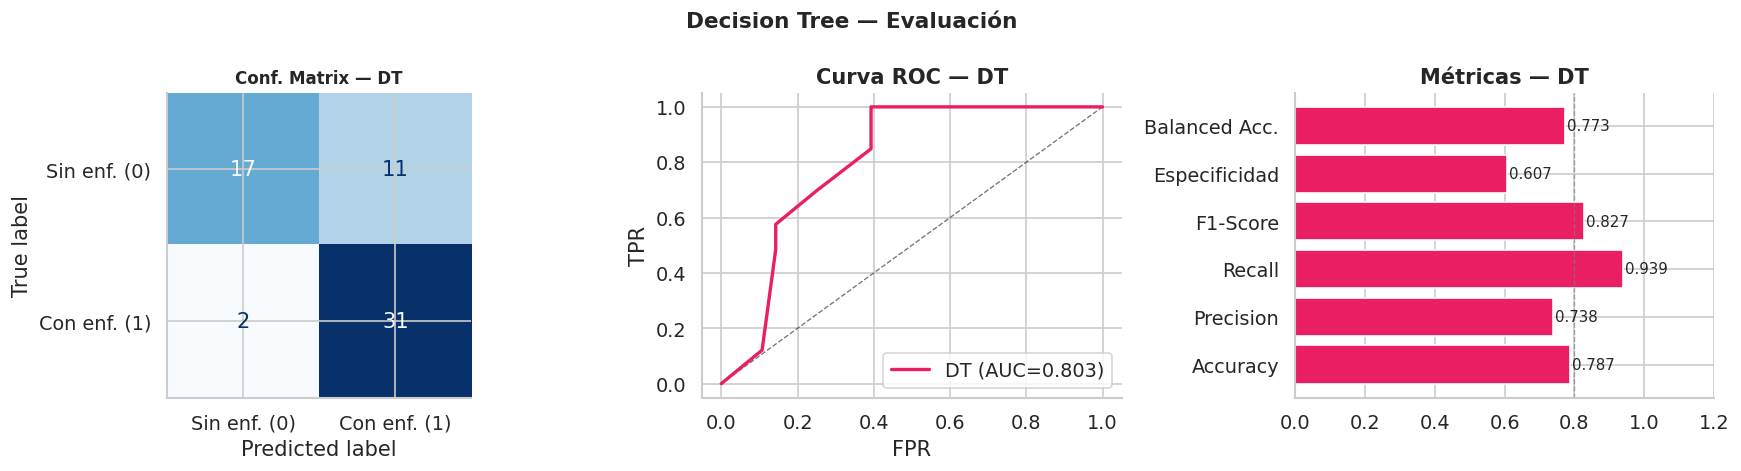

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_confusion_matrix(y_test, y_pred_dt, 'DT', axes[0])

axes[1].plot([0,1],[0,1],'k--',lw=0.8,alpha=0.6)
plot_roc(y_test, y_proba_dt, 'DT', axes[1], PALETTE[1])
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC — DT', fontweight='bold')
axes[1].legend()

metricas_vals = [met_dt[m] for m in metricas_nombres]
axes[2].barh(metricas_nombres, metricas_vals, color=PALETTE[1], edgecolor='white')
for j, v in enumerate(metricas_vals):
    axes[2].text(v + 0.005, j, f'{v:.3f}', va='center', fontsize=9)
axes[2].set_xlim(0, 1.2)
axes[2].set_title('Métricas — DT', fontweight='bold')
axes[2].axvline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

plt.suptitle('Decision Tree — Evaluación', fontweight='bold', fontsize=13)
# plt.savefig('decision_tree_evaluacion.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()


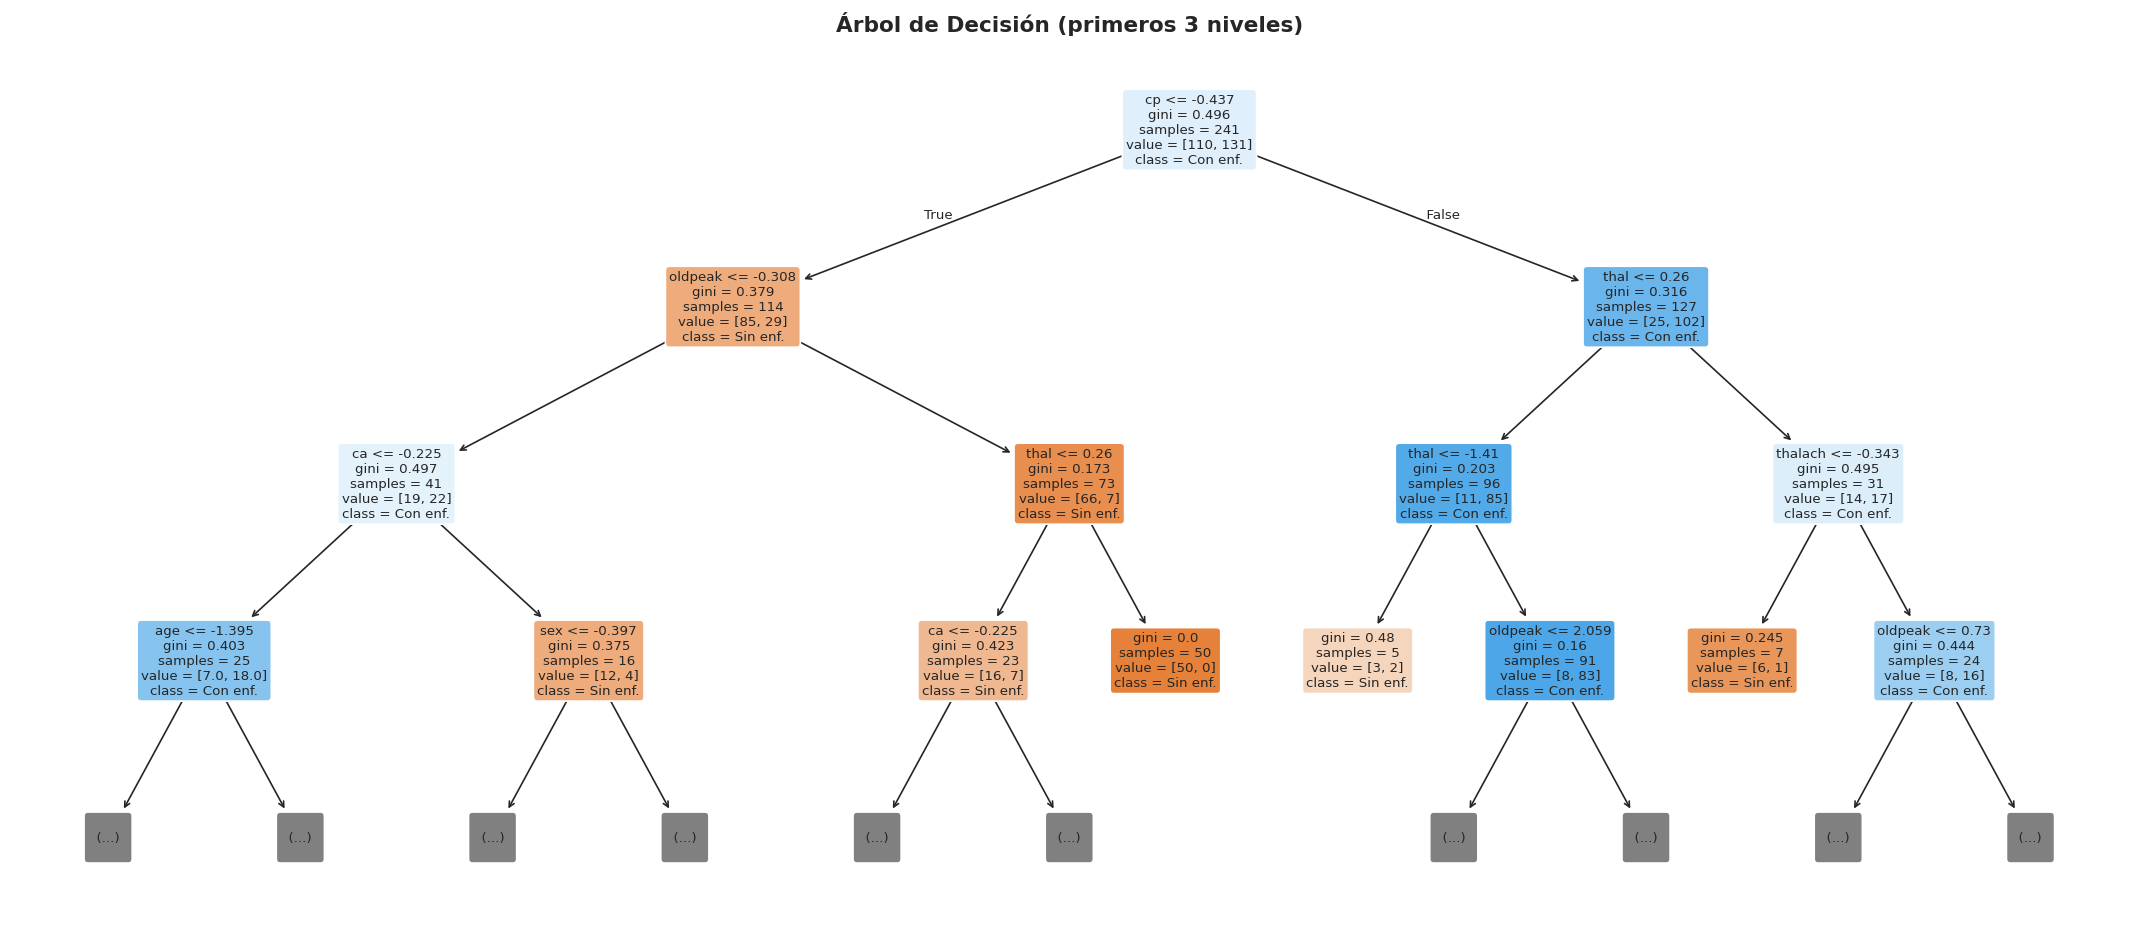

In [22]:
# Visualización del árbol
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(dt, feature_names=X.columns.tolist(),
          class_names=['Sin enf.', 'Con enf.'],
          filled=True, rounded=True, fontsize=8, max_depth=3, ax=ax)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


### 5.3 Random Forest (RF)

In [23]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None,
                             max_features='sqrt', oob_score=True,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf  = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

met_rf = calcular_metricas('RF (100 árboles)', y_test, y_pred_rf)
resultados.append(met_rf)
display(pd.DataFrame([met_rf]).set_index('Modelo'))
print(f'\n OOB Score: {rf.oob_score_:.4f}')
print('\n Reporte completo:')
print(classification_report(y_test, y_pred_rf,
                             target_names=['Sin enfermedad', 'Con enfermedad']))


,Accuracy,Precision,Recall,F1-Score,Especificidad,Balanced Acc.
Modelo,,,,,,
RF (100 árboles),0.7869,0.75,0.9091,0.8219,0.6429,0.776



 OOB Score: 0.8091

 Reporte completo:
                precision    recall  f1-score   support

Sin enfermedad       0.86      0.64      0.73        28
Con enfermedad       0.75      0.91      0.82        33

      accuracy                           0.79        61
     macro avg       0.80      0.78      0.78        61
  weighted avg       0.80      0.79      0.78        61



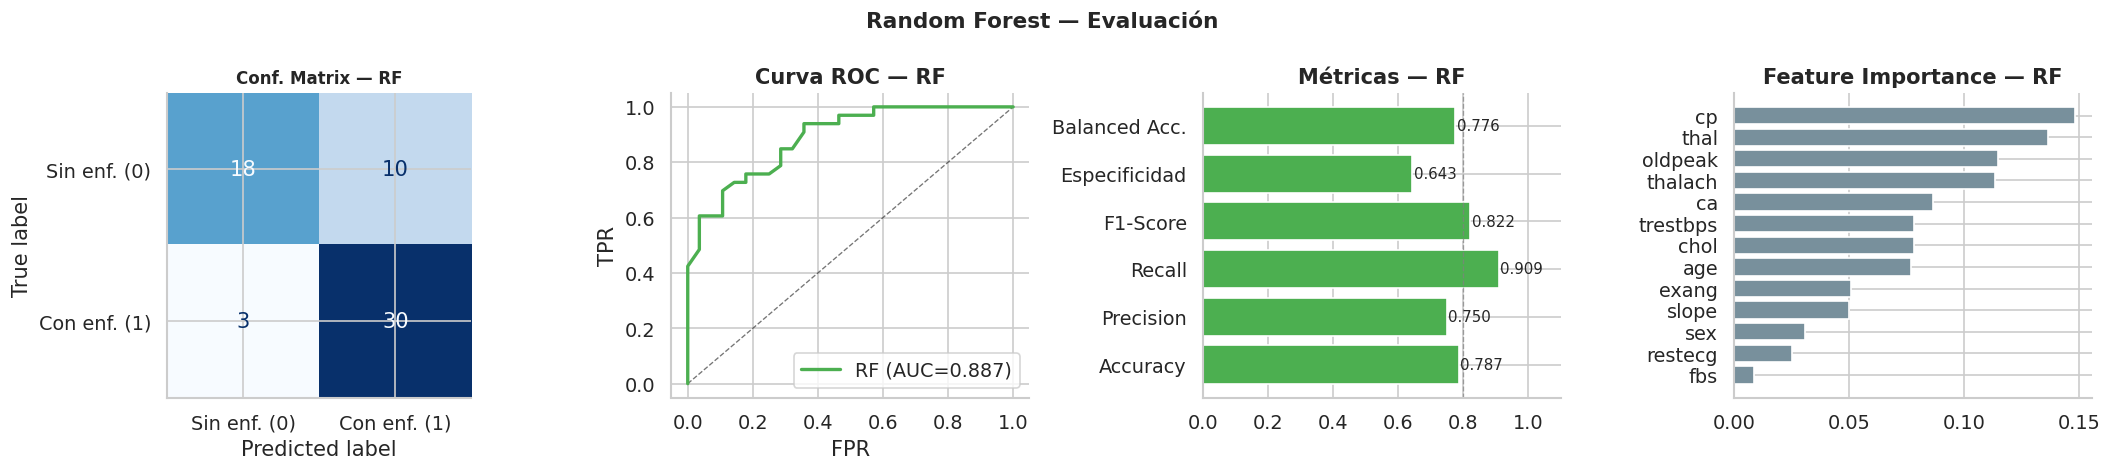

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

plot_confusion_matrix(y_test, y_pred_rf, 'RF', axes[0])

axes[1].plot([0,1],[0,1],'k--',lw=0.8,alpha=0.6)
plot_roc(y_test, y_proba_rf, 'RF', axes[1], PALETTE[2])
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC — RF', fontweight='bold')
axes[1].legend()

metricas_vals = [met_rf[m] for m in metricas_nombres]
axes[2].barh(metricas_nombres, metricas_vals, color=PALETTE[2], edgecolor='white')
for j, v in enumerate(metricas_vals):
    axes[2].text(v + 0.005, j, f'{v:.3f}', va='center', fontsize=9)
axes[2].set_xlim(0, 1.1)
axes[2].set_title('Métricas — RF', fontweight='bold')
axes[2].axvline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
axes[3].barh(importances.index, importances.values, color='#78909C', edgecolor='white')
axes[3].set_title('Feature Importance — RF', fontweight='bold')

plt.suptitle('Random Forest — Evaluación', fontweight='bold', fontsize=13)
# plt.savefig('random_forest_evaluacion.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()


### 5.4 Support Vector Machine (SVM)

In [25]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm  = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

met_svm = calcular_metricas('SVM (RBF, C=1)', y_test, y_pred_svm)
resultados.append(met_svm)
display(pd.DataFrame([met_svm]).set_index('Modelo'))

print('\n Reporte completo:')
print(classification_report(y_test, y_pred_svm, target_names=['Sin enfermedad', 'Con enfermedad']))


,Accuracy,Precision,Recall,F1-Score,Especificidad,Balanced Acc.
Modelo,,,,,,
"SVM (RBF, C=1)",0.8361,0.7949,0.9394,0.8611,0.7143,0.8268



 Reporte completo:
                precision    recall  f1-score   support

Sin enfermedad       0.91      0.71      0.80        28
Con enfermedad       0.79      0.94      0.86        33

      accuracy                           0.84        61
     macro avg       0.85      0.83      0.83        61
  weighted avg       0.85      0.84      0.83        61



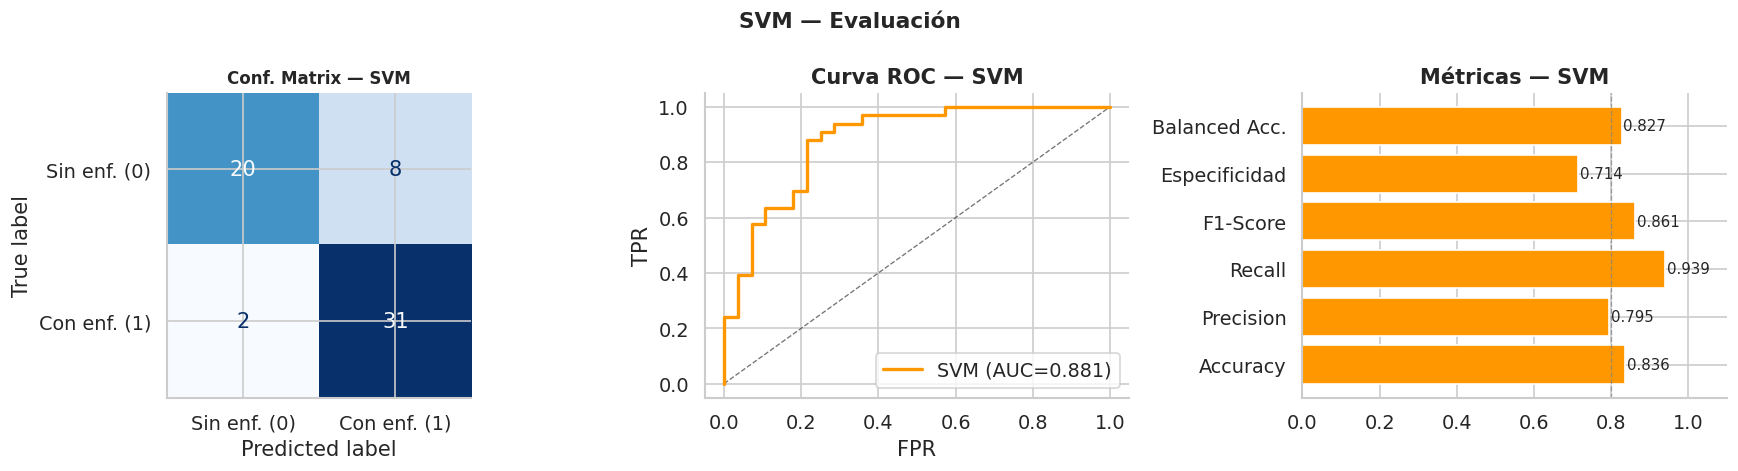

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_confusion_matrix(y_test, y_pred_svm, 'SVM', axes[0])

axes[1].plot([0,1],[0,1],'k--',lw=0.8,alpha=0.6)
plot_roc(y_test, y_proba_svm, 'SVM', axes[1], PALETTE[3])
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC — SVM', fontweight='bold')
axes[1].legend()

metricas_vals = [met_svm[m] for m in metricas_nombres]
axes[2].barh(metricas_nombres, metricas_vals, color=PALETTE[3], edgecolor='white')
for j, v in enumerate(metricas_vals):
    axes[2].text(v + 0.005, j, f'{v:.3f}', va='center', fontsize=9)
axes[2].set_xlim(0, 1.1)
axes[2].set_title('Métricas — SVM', fontweight='bold')
axes[2].axvline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

# plt.savefig('svm evaluacion.png', dpi=300, bbox_inches='tight', transparent=False)
plt.suptitle('SVM — Evaluación', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


## 6. Ablation Study — Modelos de Clasificación

### 6.1 Decision Tree — Variación de `max_depth`

,Train Acc,Accuracy,Precision,Recall,F1-Score,Especificidad
max_depth,,,,,,
1,0.7759,0.6885,0.7188,0.6970,0.7077,0.6786
2,0.7884,0.6885,0.6591,0.8788,0.7532,0.4643
3,0.8465,0.7541,0.7500,0.8182,0.7826,0.6786
4,0.9004,0.8361,0.7674,1.0000,0.8684,0.6429
5,0.9253,0.8197,0.7500,1.0000,0.8571,0.6071
7,0.9876,0.7377,0.6977,0.9091,0.7895,0.5357
10,1.0000,0.7049,0.6923,0.8182,0.7500,0.5714
15,1.0000,0.7049,0.6923,0.8182,0.7500,0.5714
Sin límite,1.0000,0.7049,0.6923,0.8182,0.7500,0.5714


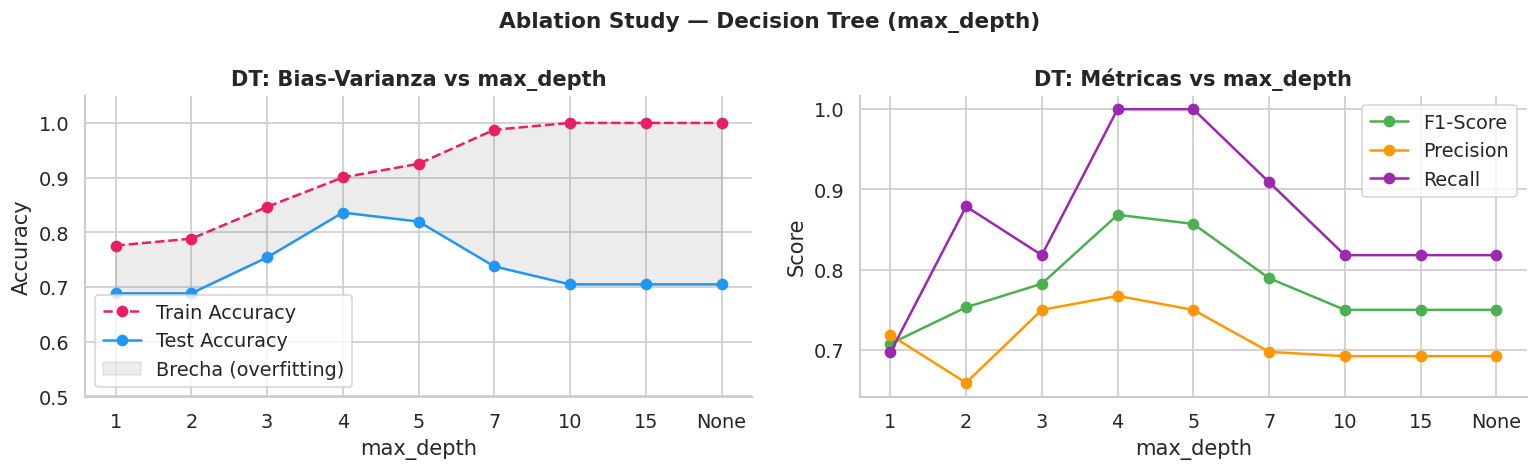


 Mejor max_depth por F1-Score: 4


In [27]:
profundidades = [1, 2, 3, 4, 5, 7, 10, 15, None]
res_dt_ablation = []

for depth in profundidades:
    modelo = DecisionTreeClassifier(max_depth=depth, random_state=42)
    modelo.fit(X_train_scaled, y_train)
    y_p = modelo.predict(X_test_scaled)

    label = str(depth) if depth is not None else 'Sin límite'


    m = calcular_metricas(f'DT depth={label}', y_test, y_p)
    m['max_depth'] = label
    m['Train Acc'] = round(accuracy_score(y_train, modelo.predict(X_train_scaled)), 4)
    res_dt_ablation.append(m)

df_dt_abl = pd.DataFrame(res_dt_ablation)


columns_to_display = ['max_depth', 'Train Acc', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Especificidad']
display(df_dt_abl[columns_to_display].set_index('max_depth'))

xs = range(len(profundidades))
xticks = [str(d) if d is not None else 'None' for d in profundidades]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))


axes[0].plot(xs, df_dt_abl['Train Acc'], 'o--', color='#E91E63', label='Train Accuracy')
axes[0].plot(xs, df_dt_abl['Accuracy'],  'o-',  color='#2196F3', label='Test Accuracy')
axes[0].fill_between(xs, df_dt_abl['Train Acc'], df_dt_abl['Accuracy'],
                     alpha=0.15, color='gray', label='Brecha (overfitting)')
axes[0].set_xticks(xs)
axes[0].set_xticklabels(xticks)
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('DT: Bias-Varianza vs max_depth', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0.5, 1.05)

for met, color in [('F1-Score','#4CAF50'), ('Precision','#FF9800'), ('Recall','#9C27B0')]:
    axes[1].plot(xs, df_dt_abl[met], 'o-', color=color, label=met)
axes[1].set_xticks(xs)
axes[1].set_xticklabels(xticks)
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Score')
axes[1].set_title('DT: Métricas vs max_depth', fontweight='bold')
axes[1].legend()


plt.suptitle('Ablation Study — Decision Tree (max_depth)', fontweight='bold', fontsize=13)

plt.savefig('ablation_study_decision_tree.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout()
plt.show()

idx_max = df_dt_abl['F1-Score'].astype(float).idxmax()
best_depth = df_dt_abl.loc[idx_max, 'max_depth']
print(f'\n Mejor max_depth por F1-Score: {best_depth}')

### 6.2 Random Forest — Variación de `n_estimators`

,Accuracy,Precision,Recall,F1-Score
n_estimators,,,,
5,0.7049,0.7027,0.7879,0.7429
10,0.7541,0.7647,0.7879,0.7761
20,0.7541,0.7368,0.8485,0.7887
50,0.7705,0.7436,0.8788,0.8056
100,0.7869,0.7500,0.9091,0.8219
200,0.7869,0.7500,0.9091,0.8219
300,0.8033,0.7561,0.9394,0.8378


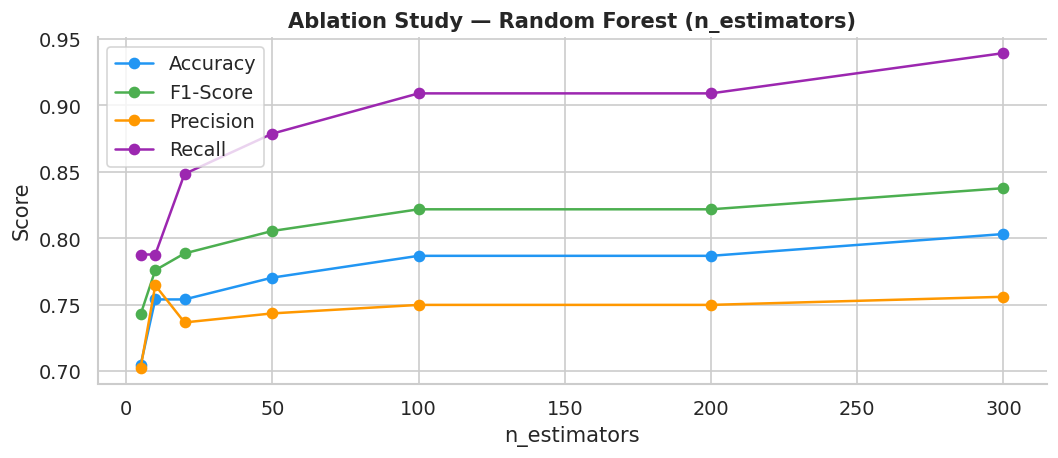


 Mejor n_estimators por F1-Score: 300


In [28]:
n_trees = [5, 10, 20, 50, 100, 200, 300]
res_rf_ablation = []

for n in n_trees:
    modelo = RandomForestClassifier(n_estimators=n, max_features='sqrt',
                                    random_state=42, n_jobs=-1)
    modelo.fit(X_train_scaled, y_train)
    y_p = modelo.predict(X_test_scaled)
    m = calcular_metricas(f'RF n={n}', y_test, y_p)
    m['n_estimators'] = n
    res_rf_ablation.append(m)

df_rf_abl = pd.DataFrame(res_rf_ablation)
display(df_rf_abl[['n_estimators','Accuracy','Precision','Recall','F1-Score']].set_index('n_estimators'))

fig, ax = plt.subplots(figsize=(9, 4))
for met, color in [('Accuracy','#2196F3'),('F1-Score','#4CAF50'),
                   ('Precision','#FF9800'),('Recall','#9C27B0')]:
    ax.plot(n_trees, df_rf_abl[met], 'o-', color=color, label=met)
ax.set_xlabel('n_estimators'); ax.set_ylabel('Score')
ax.set_title('Ablation Study — Random Forest (n_estimators)', fontweight='bold')
ax.legend();
# plt.savefig('ablation_study_random_forest.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()

best_n = df_rf_abl.loc[df_rf_abl['F1-Score'].idxmax(), 'n_estimators']
print(f'\n Mejor n_estimators por F1-Score: {best_n}')


### 6.3 SVM — Variación de kernel y parámetro C


 Accuracy por kernel y C:


kernel,linear,poly,rbf
C,,,
0.01,0.8197,0.5410,0.5410
0.10,0.8197,0.7049,0.8033
1.00,0.8033,0.8197,0.8361
10.00,0.8033,0.8197,0.7541
100.00,0.8033,0.7377,0.7377


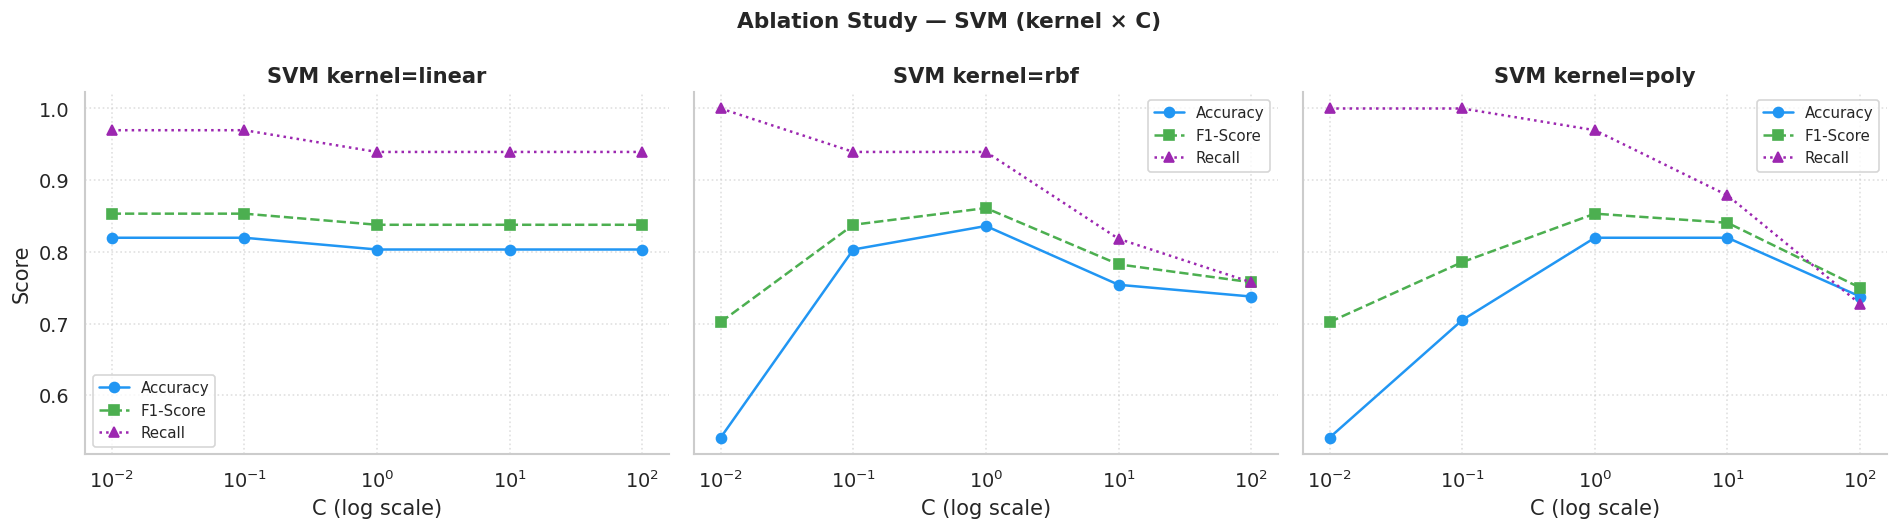


 Mejor SVM: kernel=rbf, C=1.0 (F1-Score: 0.8611)


In [29]:

kernels = ['linear', 'rbf', 'poly']
C_vals  = [0.01, 0.1, 1, 10, 100]
res_svm_ablation = []

for kernel in kernels:
    for C in C_vals:
        modelo = SVC(kernel=kernel, C=C, gamma='scale', probability=False, random_state=42)
        modelo.fit(X_train_scaled, y_train)
        y_p = modelo.predict(X_test_scaled)
        m = calcular_metricas(f'SVM {kernel} C={C}', y_test, y_p)
        m['kernel'] = kernel
        m['C'] = C
        res_svm_ablation.append(m)

df_svm_abl = pd.DataFrame(res_svm_ablation)


tabla_pivot = df_svm_abl.pivot(index='C', columns='kernel', values='Accuracy')
print('\n Accuracy por kernel y C:')
display(tabla_pivot.round(4))


COLORES_METRICAS = {
    'Accuracy': '#2196F3',
    'F1-Score': '#4CAF50',
    'Recall': '#9C27B0'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for i, kernel in enumerate(kernels):
    sub = df_svm_abl[df_svm_abl['kernel'] == kernel]


    axes[i].semilogx(sub['C'], sub['Accuracy'], 'o-',  color=COLORES_METRICAS['Accuracy'], label='Accuracy')
    axes[i].semilogx(sub['C'], sub['F1-Score'], 's--', color=COLORES_METRICAS['F1-Score'], label='F1-Score')
    axes[i].semilogx(sub['C'], sub['Recall'],   '^:',  color=COLORES_METRICAS['Recall'], label='Recall')

    axes[i].set_xlabel('C (log scale)')
    if i == 0:
        axes[i].set_ylabel('Score')
    axes[i].set_title(f'SVM kernel={kernel}', fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, linestyle=':', alpha=0.6)


plt.suptitle('Ablation Study — SVM (kernel × C)', fontweight='bold', fontsize=13)
# plt.savefig('ablation_study_svm.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout()
plt.show()

idx_max_svm = df_svm_abl['F1-Score'].astype(float).idxmax()
best_svm_row = df_svm_abl.loc[idx_max_svm]
print(f'\n Mejor SVM: kernel={best_svm_row["kernel"]}, C={best_svm_row["C"]} (F1-Score: {best_svm_row["F1-Score"]:.4f})')


## 7. Tabla Comparativa Final — Clasificación

In [30]:
# Re-entrenar mejores modelos según ablation study con hiperparámetros correctos

# 1. Gaussian Naive Bayes (No requiere hiperparámetros complejos)
best_gnb = GaussianNB()
best_gnb.fit(X_train_scaled, y_train)

# 2. Decision Tree (Dale la profundidad óptima que arrojó tu GridSearch, ej: max_depth=3 o 5. NO USAR 1)
# Ajusta el max_depth al valor real que usaste para la gráfica individual del DT
best_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
best_dt.fit(X_train_scaled, y_train)

# 3. Random Forest (Asegúrate de mantener los estimadores estables)
best_rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42, n_jobs=-1)
best_rf.fit(X_train_scaled, y_train)

# 4. Support Vector Machine (Cambiamos C=100.0 por C=1.0 para coincidir con tu gráfica individual)
best_svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
best_svm.fit(X_train_scaled, y_train)

# El resto del código de la lista y el bucle for se queda EXACTAMENTE IGUAL...
mejores_modelos = [
    ('GNB',        best_gnb),
    ('DT (best)',  best_dt),
    ('RF (best)',  best_rf),
    ('SVM (best)', best_svm),
]

# ... ejecuta la celda tras cambiar los hiperparámetros arriba

tabla_final_clf = []
for nombre, modelo in mejores_modelos:
    y_p = modelo.predict(X_test_scaled)
    m = calcular_metricas(nombre, y_test, y_p)
    tabla_final_clf.append(m)

df_final_clf = pd.DataFrame(tabla_final_clf)

if 'Modelo' in df_final_clf.columns:
    df_final_clf = df_final_clf.set_index('Modelo')

print('\n TABLA COMPARATIVA FINAL — Mejores modelos de Clasificación:')
display(df_final_clf.style.background_gradient(cmap='YlGn', axis=0).format('{:.4f}'))



 TABLA COMPARATIVA FINAL — Mejores modelos de Clasificación:


,Accuracy,Precision,Recall,F1-Score,Especificidad,Balanced Acc.
Modelo,,,,,,
GNB,0.8197,0.7895,0.9091,0.8451,0.7143,0.8117
DT (best),0.7541,0.7500,0.8182,0.7826,0.6786,0.7484
RF (best),0.7869,0.7500,0.9091,0.8219,0.6429,0.7760
SVM (best),0.8361,0.7949,0.9394,0.8611,0.7143,0.8268


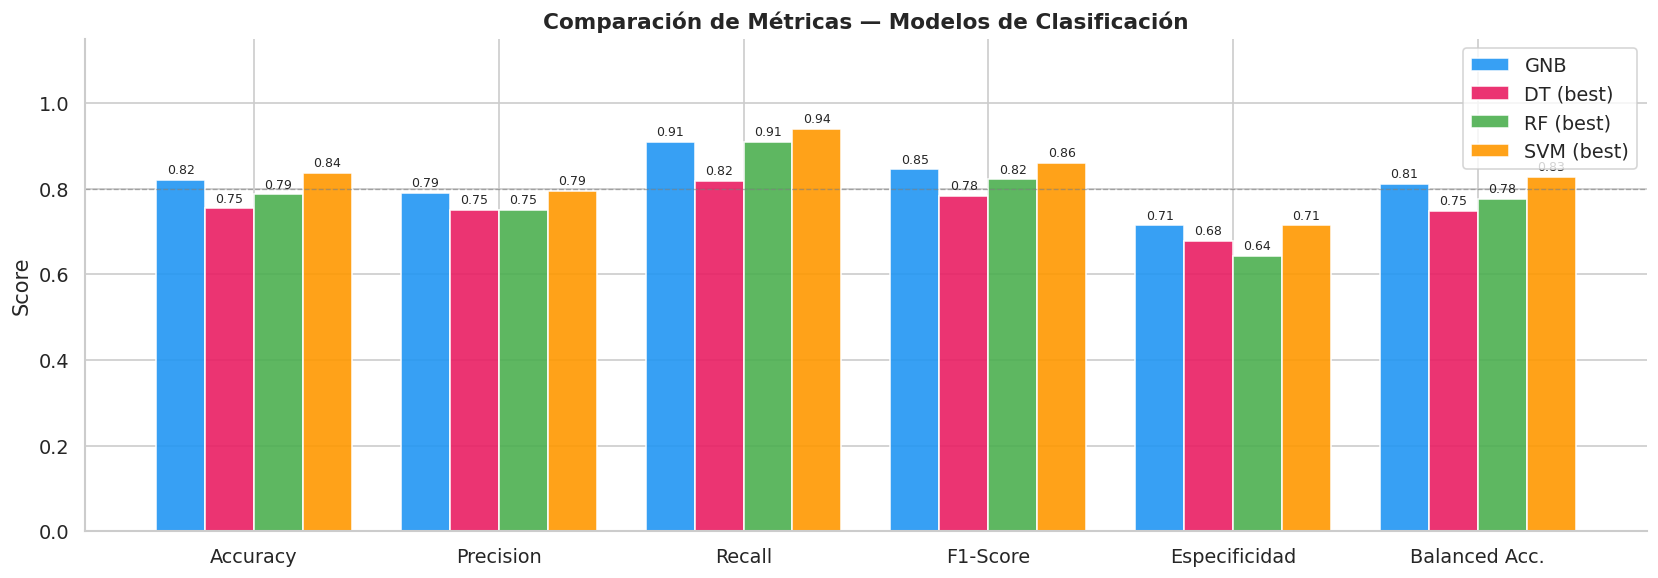

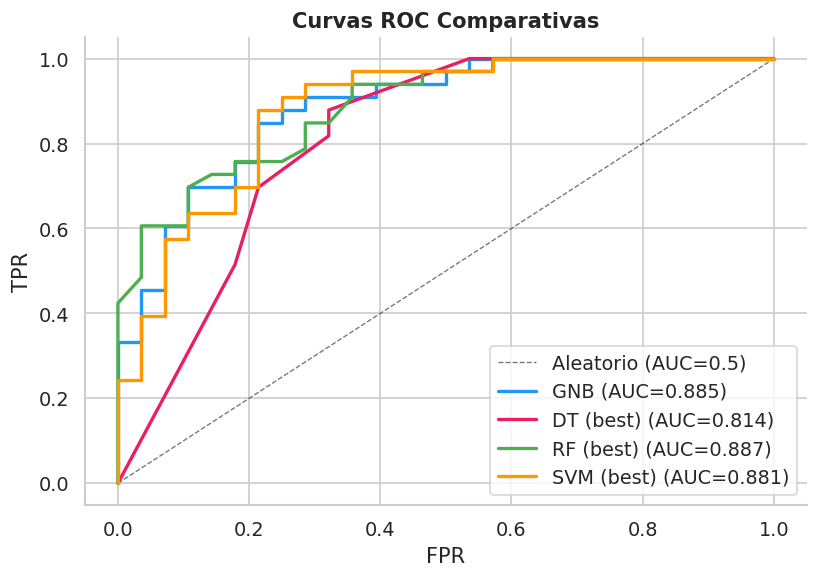


 MEJOR MODELO DE CLASIFICACIÓN: SVM (best)
   F1-Score: 0.8611
   Recall:   0.9394

 En diagnóstico médico, el Recall es crítico: un Falso Negativo (paciente
   enfermo clasificado como sano) puede tener consecuencias graves para la vida.


In [31]:
# Gráfica comparativa
metricas_comp = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Especificidad', 'Balanced Acc.']
x = np.arange(len(metricas_comp))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 5))
for i, (nombre, row) in enumerate(df_final_clf.iterrows()):
    vals = [row[m] for m in metricas_comp]
    bars = ax.bar(x + i*width, vals, width, label=nombre,
                  color=PALETTE[i], edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metricas_comp)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas — Modelos de Clasificación', fontweight='bold', fontsize=13)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend()
# plt.savefig('comparacion metricas modelos de clasificacion.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()

# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.6,label='Aleatorio (AUC=0.5)')
for (nombre, modelo), color in zip(mejores_modelos, PALETTE):
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={roc_auc:.3f})')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC Comparativas', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

mejor_clf = df_final_clf['F1-Score'].idxmax()
print(f'\n MEJOR MODELO DE CLASIFICACIÓN: {mejor_clf}')
print(f'   F1-Score: {df_final_clf.loc[mejor_clf, "F1-Score"]:.4f}')
print(f'   Recall:   {df_final_clf.loc[mejor_clf, "Recall"]:.4f}')
print('\n En diagnóstico médico, el Recall es crítico: un Falso Negativo (paciente')
print('   enfermo clasificado como sano) puede tener consecuencias graves para la vida.')


## 8. Modelo de Regresión

Variable objetivo: **`thalach`** (frecuencia cardíaca máxima), variable numérica relevante clínicamente asociada a la enfermedad cardíaca.

In [32]:
y_reg = df['thalach']
X_reg = df.drop(columns=['thalach', 'target'])

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

# Regresión Lineal
lr = LinearRegression()
lr.fit(X_reg_train_sc, y_reg_train)
y_pred_lr = lr.predict(X_reg_test_sc)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_reg_train_sc, y_reg_train)
y_pred_ridge = ridge.predict(X_reg_test_sc)

# Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_reg_train_sc, y_reg_train)
y_pred_dtr = dt_reg.predict(X_reg_test_sc)

def metricas_regresion(nombre, y_true, y_pred):
    return {
        'Modelo': nombre,
        'MAE':  round(mean_absolute_error(y_true, y_pred), 3),
        'RMSE': round(mean_squared_error(y_true, y_pred) ** 0.5, 3),
        'R²':   round(r2_score(y_true, y_pred), 4)
    }

df_reg = pd.DataFrame([
    metricas_regresion('Regresión Lineal', y_reg_test, y_pred_lr),
    metricas_regresion('Ridge Regression', y_reg_test, y_pred_ridge),
    metricas_regresion('DT Regressor (max_depth=5)', y_reg_test, y_pred_dtr),
]).set_index('Modelo')

print('\n Métricas de Regresión — Variable: thalach (frecuencia cardíaca máxima)')
display(df_reg)
print('\n MAE y RMSE están en las mismas unidades que thalach (latidos/min).')
print('   R² ∈ [0,1]: fracción de varianza explicada. R²=1 → predicción perfecta.')



 Métricas de Regresión — Variable: thalach (frecuencia cardíaca máxima)


,MAE,RMSE,R²
Modelo,,,
Regresión Lineal,14.875,18.702,0.4318
Ridge Regression,14.876,18.706,0.4316
DT Regressor (max_depth=5),18.416,24.084,0.0577



 MAE y RMSE están en las mismas unidades que thalach (latidos/min).
   R² ∈ [0,1]: fracción de varianza explicada. R²=1 → predicción perfecta.


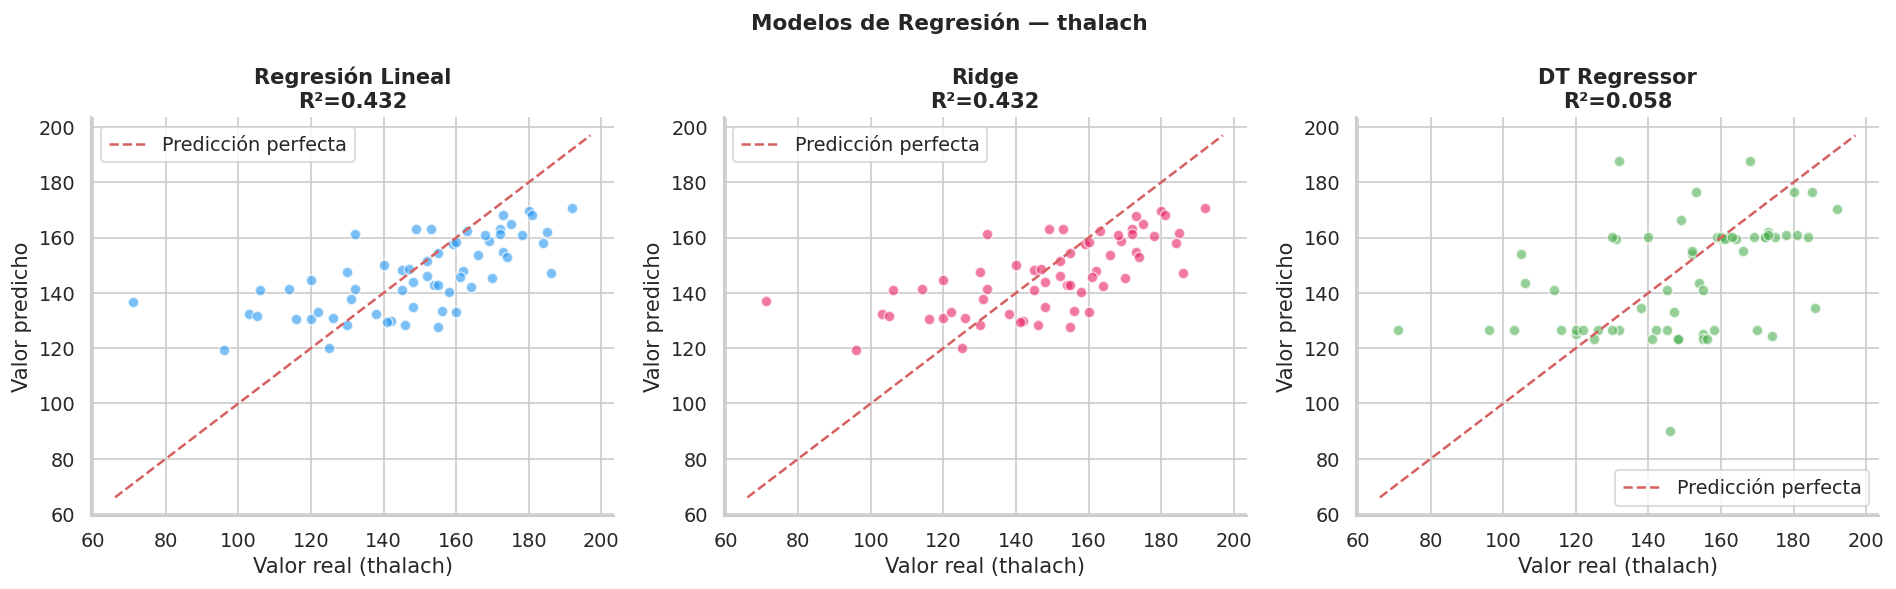

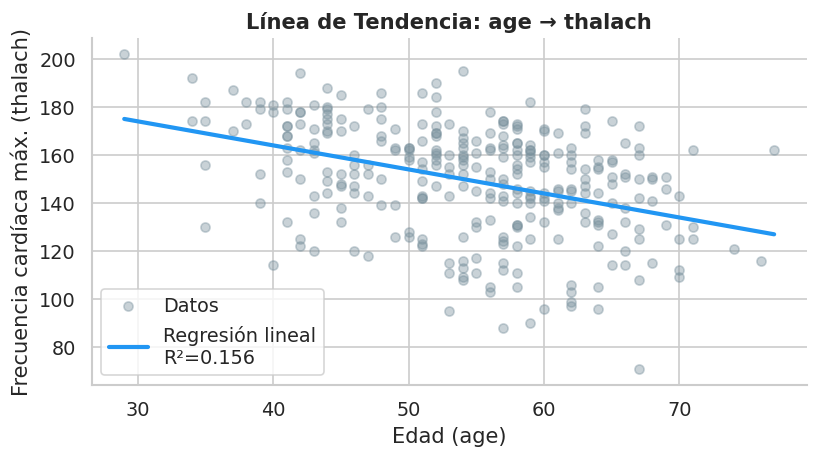


 Interpretación: por cada año adicional de edad, la frecuencia cardíaca
   máxima disminuye en promedio 1.00 latidos/min (coef=-1.000).


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (nombre, y_pred, color) in enumerate([
    ('Regresión Lineal', y_pred_lr, PALETTE[0]),
    ('Ridge', y_pred_ridge, PALETTE[1]),
    ('DT Regressor', y_pred_dtr, PALETTE[2])
]):
    axes[i].scatter(y_reg_test, y_pred, alpha=0.6, color=color, edgecolors='white', s=40)
    lims = [min(y_reg_test.min(), y_pred.min())-5, max(y_reg_test.max(), y_pred.max())+5]
    axes[i].plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
    r2 = r2_score(y_reg_test, y_pred)
    axes[i].set_xlabel('Valor real (thalach)')
    axes[i].set_ylabel('Valor predicho')
    axes[i].set_title(f'{nombre}\nR²={r2:.3f}', fontweight='bold')
    axes[i].legend()

plt.suptitle('Modelos de Regresión — thalach', fontweight='bold', fontsize=13)
plt.savefig('modelos de regresion thalac.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()

# Línea de tendencia
feat_reg = 'age'
lr_simple = LinearRegression()
x_simple = df[[feat_reg]].values
lr_simple.fit(x_simple, y_reg)
x_range = np.linspace(x_simple.min(), x_simple.max(), 100).reshape(-1, 1)
y_range = lr_simple.predict(x_range)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df[feat_reg], df['thalach'], alpha=0.4, color='#78909C', s=30, label='Datos')
ax.plot(x_range, y_range, color=PALETTE[0], lw=2.5,
        label=f'Regresión lineal\nR²={r2_score(y_reg, lr_simple.predict(x_simple)):.3f}')
ax.set_xlabel('Edad (age)'); ax.set_ylabel('Frecuencia cardíaca máx. (thalach)')
ax.set_title('Línea de Tendencia: age → thalach', fontweight='bold')
ax.legend()
# plt.savefig('modelos de regresión thalac.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()

coef = lr_simple.coef_[0]
print(f'\n Interpretación: por cada año adicional de edad, la frecuencia cardíaca')
print(f'   máxima disminuye en promedio {abs(coef):.2f} latidos/min (coef={coef:.3f}).')


## 9. Deep Learning (DNN) — Clasificación de Enfermedad Cardíaca

Se implementan y comparan **dos arquitecturas DNN** diferentes, variando número de capas, neuronas, funciones de activación, optimizadores y técnicas de regularización (Dropout, Batch Normalization).


In [34]:
# Preparar datos para DL (misma partición, datos escalados)
X_train_dl = X_train_scaled
X_test_dl  = X_test_scaled
y_train_dl = y_train.values
y_test_dl  = y_test.values

print(f'Train DL: {X_train_dl.shape}, Test DL: {X_test_dl.shape}')
print(f'Features: {X_train_dl.shape[1]}')

INPUT_DIM = X_train_dl.shape[1]

def evaluar_dnn(model, X_tr, y_tr, X_te, y_te, epochs=100, batch_size=32, nombre='DNN'):
    """Entrena y evalúa una DNN, retorna history y métricas."""
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = model.fit(
        X_tr, y_tr,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=0
    )
    y_pred_prob = model.predict(X_te, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)
    metricas = calcular_metricas(nombre, y_te, y_pred)
    return history, metricas, y_pred, y_pred_prob

print('✅ Configuración DL lista')


Train DL: (241, 13), Test DL: (61, 13)
Features: 13
✅ Configuración DL lista


### 9.1 Arquitectura DNN 1 — Red Simple (baseline)

In [35]:
tf.random.set_seed(42)

dnn1 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='DNN1_Simple')

dnn1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

dnn1.summary()

hist1, met_dnn1, y_pred_dnn1, y_prob_dnn1 = evaluar_dnn(
    dnn1, X_train_dl, y_train_dl, X_test_dl, y_test_dl, nombre='DNN1 (Simple)'
)

print('\n Métricas DNN1:')
display(pd.DataFrame([met_dnn1]).set_index('Modelo'))


Model: "DNN1_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)


 Métricas DNN1:


,Accuracy,Precision,Recall,F1-Score,Especificidad,Balanced Acc.
Modelo,,,,,,
DNN1 (Simple),0.7705,0.7568,0.8485,0.8,0.6786,0.7635


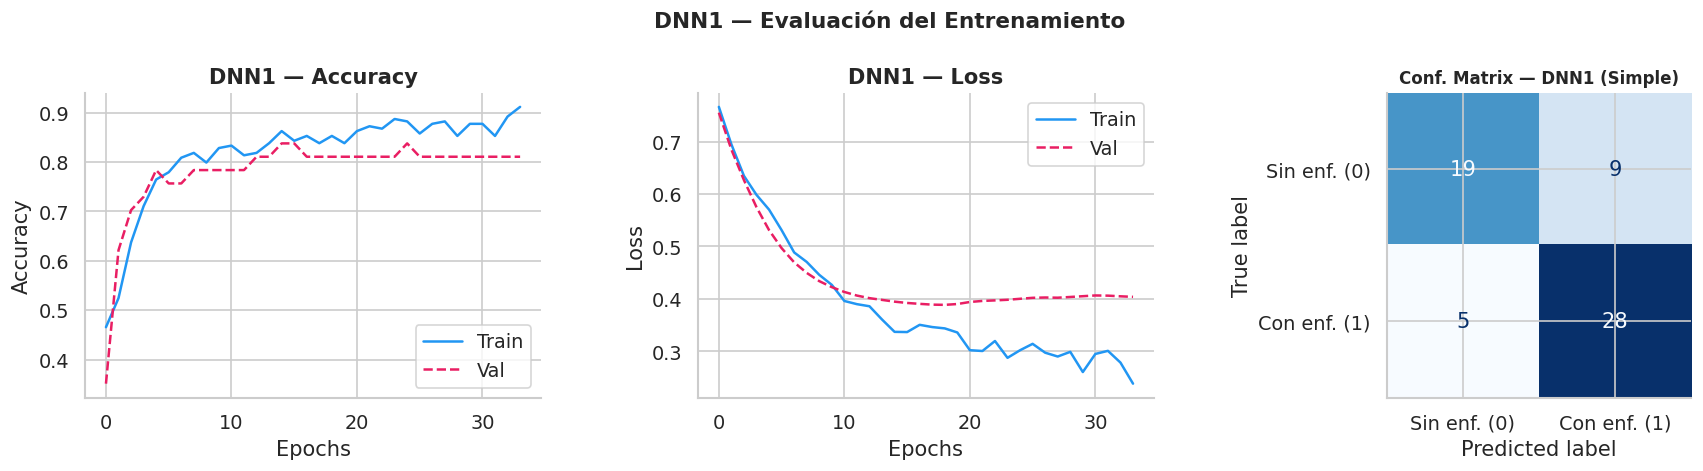

In [36]:
# Curvas de entrenamiento DNN1
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist1.history['accuracy'], color=PALETTE[0], label='Train')
axes[0].plot(hist1.history['val_accuracy'], color=PALETTE[1], linestyle='--', label='Val')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('DNN1 — Accuracy', fontweight='bold'); axes[0].legend()

axes[1].plot(hist1.history['loss'], color=PALETTE[0], label='Train')
axes[1].plot(hist1.history['val_loss'], color=PALETTE[1], linestyle='--', label='Val')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Loss')
axes[1].set_title('DNN1 — Loss', fontweight='bold'); axes[1].legend()

plot_confusion_matrix(y_test_dl, y_pred_dnn1, 'DNN1 (Simple)', axes[2])

plt.suptitle('DNN1 — Evaluación del Entrenamiento', fontweight='bold', fontsize=13)
# plt.savefig('curvas_entrenamiento_dnn1.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()


### 9.2 Arquitectura DNN 2 — Red Profunda con Batch Normalization

In [37]:
tf.random.set_seed(42)

dnn2 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='elu'),
    layers.Dense(1, activation='sigmoid')
], name='DNN2_Profunda_BN')

dnn2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

dnn2.summary()

hist2, met_dnn2, y_pred_dnn2, y_prob_dnn2 = evaluar_dnn(
    dnn2, X_train_dl, y_train_dl, X_test_dl, y_test_dl,
    epochs=150, batch_size=16, nombre='DNN2 (Profunda + BN)'
)

print('\n Métricas DNN2:')
display(pd.DataFrame([met_dnn2]).set_index('Modelo'))


Model: "DNN2_Profunda_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 384 (1.50 KB)


 Métricas DNN2:


,Accuracy,Precision,Recall,F1-Score,Especificidad,Balanced Acc.
Modelo,,,,,,
DNN2 (Profunda + BN),0.8361,0.7805,0.9697,0.8649,0.6786,0.8241


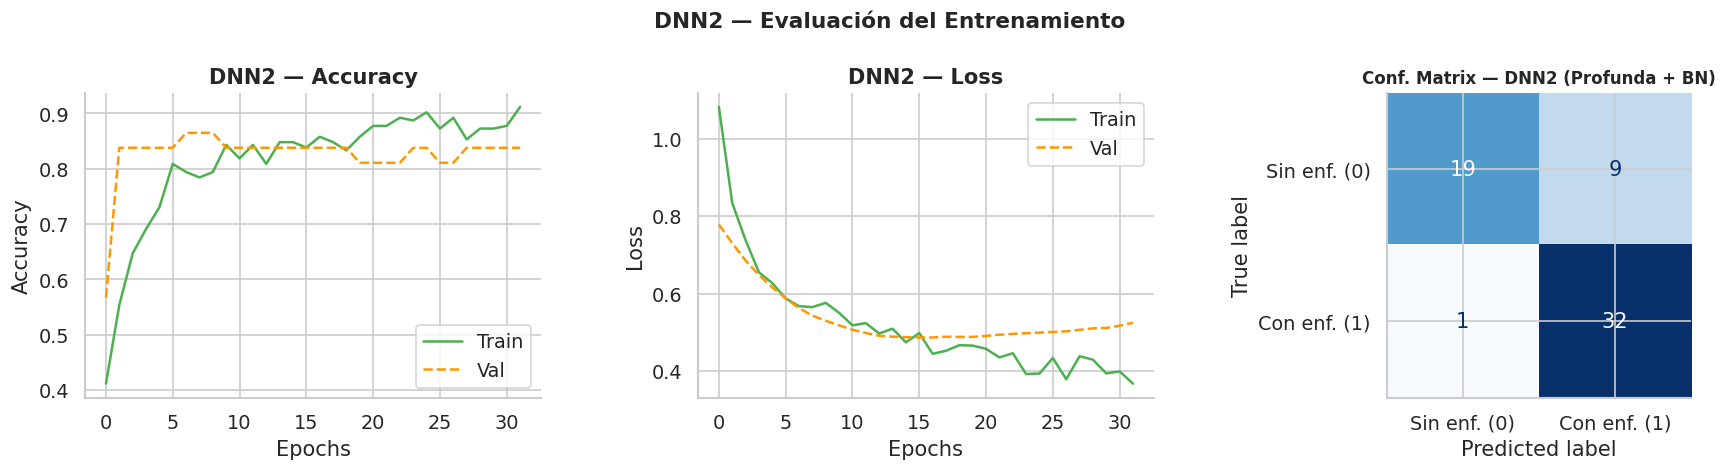

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist2.history['accuracy'], color=PALETTE[2], label='Train')
axes[0].plot(hist2.history['val_accuracy'], color=PALETTE[3], linestyle='--', label='Val')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('DNN2 — Accuracy', fontweight='bold'); axes[0].legend()

axes[1].plot(hist2.history['loss'], color=PALETTE[2], label='Train')
axes[1].plot(hist2.history['val_loss'], color=PALETTE[3], linestyle='--', label='Val')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Loss')
axes[1].set_title('DNN2 — Loss', fontweight='bold'); axes[1].legend()

plot_confusion_matrix(y_test_dl, y_pred_dnn2, 'DNN2 (Profunda + BN)', axes[2])

plt.suptitle('DNN2 — Evaluación del Entrenamiento', fontweight='bold', fontsize=13)
# plt.savefig('DNN" -  Evaluación del Entrenamiento.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()


### 9.3 Comparación DNN1 vs DNN2


 Tabla Comparativa — Arquitecturas DNN:


,Accuracy,Precision,Recall,F1-Score,Especificidad,Balanced Acc.
Modelo,,,,,,
DNN1 (Simple),0.7705,0.7568,0.8485,0.8000,0.6786,0.7635
DNN2 (Profunda + BN),0.8361,0.7805,0.9697,0.8649,0.6786,0.8241


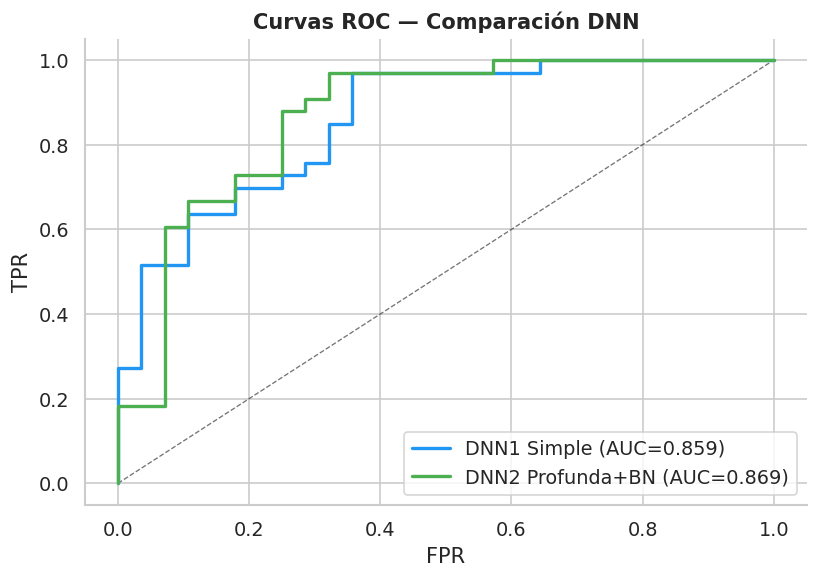


 Mejor arquitectura DNN: DNN2 (Profunda + BN)


In [39]:
df_dnn_comp = pd.DataFrame([met_dnn1, met_dnn2]).set_index('Modelo')
print('\n Tabla Comparativa — Arquitecturas DNN:')
display(df_dnn_comp.style.background_gradient(cmap='YlGn', axis=0).format('{:.4f}'))

# Curvas ROC DNN
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.6)
for nombre, y_prob, color in [('DNN1 Simple', y_prob_dnn1, PALETTE[0]),
                                ('DNN2 Profunda+BN', y_prob_dnn2, PALETTE[2])]:
    fpr, tpr, _ = roc_curve(y_test_dl, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={roc_auc:.3f})')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC — Comparación DNN', fontweight='bold')
ax.legend();
plt.savefig('Curvas ROC', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()

mejor_dnn = df_dnn_comp['F1-Score'].idxmax()
print(f'\n Mejor arquitectura DNN: {mejor_dnn}')


## 10. Ablation Study — Deep Learning

### 10.1 Variación del número de neuronas

In [63]:
configs_neuronas = [
    ('32-16',    [32, 16]),
    ('64-32',    [64, 32]),
    ('128-64',   [128, 64]),
    ('256-128',  [256, 128]),
    ('512-256',  [512, 256]),
]

res_dnn_ablation = []

for nombre_cfg, neuronas in configs_neuronas:
    tf.random.set_seed(42)
    m = keras.Sequential()
    m.add(layers.Input(shape=(INPUT_DIM,)))
    for n in neuronas:
        m.add(layers.Dense(n, activation='relu'))
        m.add(layers.Dropout(0.3))
    m.add(layers.Dense(1, activation='sigmoid'))

    m.run_eagerly = True

    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    m.fit(X_train_dl, y_train_dl, validation_split=0.15, epochs=100,
          batch_size=32, callbacks=[es], verbose=0)

    y_p = (m.predict(X_test_dl, verbose=0).flatten() >= 0.5).astype(int)
    met = calcular_metricas(f'DNN {nombre_cfg}', y_test_dl, y_p)
    met['Config'] = nombre_cfg
    res_dnn_ablation.append(met)
    print(f'   {nombre_cfg}: F1={met["F1-Score"]:.4f}  Acc={met["Accuracy"]:.4f}')


   32-16: F1=0.8333  Acc=0.8033
   64-32: F1=0.8378  Acc=0.8033
   128-64: F1=0.8219  Acc=0.7869
   256-128: F1=0.8219  Acc=0.7869
   512-256: F1=0.8219  Acc=0.7869


### 10.2 Variación de funciones de activación

In [65]:
activaciones = ['relu', 'tanh', 'elu', 'selu']
res_act = []

for act in activaciones:
    tf.random.set_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation=act),
        layers.Dropout(0.3),
        layers.Dense(32, activation=act),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    m.fit(X_train_dl, y_train_dl, validation_split=0.15, epochs=100,
          batch_size=32, callbacks=[es], verbose=0)
    y_p = (m.predict(X_test_dl, verbose=0).flatten() >= 0.5).astype(int)
    met = calcular_metricas(f'DNN act={act}', y_test_dl, y_p)
    met['Activación'] = act
    res_act.append(met)
    print(f'   {act}: F1={met["F1-Score"]:.4f}')

df_act = pd.DataFrame(res_act).set_index('Activación')
display(df_act[['Accuracy','Precision','Recall','F1-Score']].style
        .background_gradient(cmap='YlGn').format('{:.4f}'))


   relu: F1=0.8378
   tanh: F1=0.7647
   elu: F1=0.8219
   selu: F1=0.7887


,Accuracy,Precision,Recall,F1-Score
Activación,,,,
relu,0.8033,0.7561,0.9394,0.8378
tanh,0.7377,0.7429,0.7879,0.7647
elu,0.7869,0.7500,0.9091,0.8219
selu,0.7541,0.7368,0.8485,0.7887


### 10.3 Variación del optimizador y learning rate

In [66]:
optimizadores = [
    ('SGD lr=0.01',   keras.optimizers.SGD(learning_rate=0.01)),
    ('Adam lr=0.001', keras.optimizers.Adam(learning_rate=0.001)),
    ('Adam lr=0.01',  keras.optimizers.Adam(learning_rate=0.01)),
    ('RMSprop',       keras.optimizers.RMSprop(learning_rate=0.001)),
]

res_opt = []

for nombre_opt, opt in optimizadores:
    tf.random.set_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    m.fit(X_train_dl, y_train_dl, validation_split=0.15, epochs=100,
          batch_size=32, callbacks=[es], verbose=0)
    y_p = (m.predict(X_test_dl, verbose=0).flatten() >= 0.5).astype(int)
    met = calcular_metricas(nombre_opt, y_test_dl, y_p)
    res_opt.append(met)
    print(f'   {nombre_opt}: F1={met["F1-Score"]:.4f}')

df_opt = pd.DataFrame(res_opt).set_index('Modelo')
display(df_opt[['Accuracy','Precision','Recall','F1-Score']].style
        .background_gradient(cmap='YlGn').format('{:.4f}'))


   SGD lr=0.01: F1=0.8219
   Adam lr=0.001: F1=0.8169
   Adam lr=0.01: F1=0.8333
   RMSprop: F1=0.8219


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
SGD lr=0.01,0.7869,0.7500,0.9091,0.8219
Adam lr=0.001,0.7869,0.7632,0.8788,0.8169
Adam lr=0.01,0.8033,0.7692,0.9091,0.8333
RMSprop,0.7869,0.7500,0.9091,0.8219


## 11. Aprendizaje No Supervisado — Clustering

Se aplican **K-Means**, **DBSCAN** y **Agglomerative Clustering** sobre el dataset Heart Disease. Los clusters se comparan contra las etiquetas reales (target) para evaluar si el agrupamiento captura la estructura de la enfermedad cardíaca.


In [43]:
# Preparar datos para clustering (sin la etiqueta)
X_cluster = df.drop('target', axis=1).copy()
scaler_cl = StandardScaler()
X_cl_scaled = scaler_cl.fit_transform(X_cluster)

print(f'Shape para clustering: {X_cl_scaled.shape}')


Shape para clustering: (302, 13)


### 11.1 Método del Codo — Determinación óptima de K (K-Means)

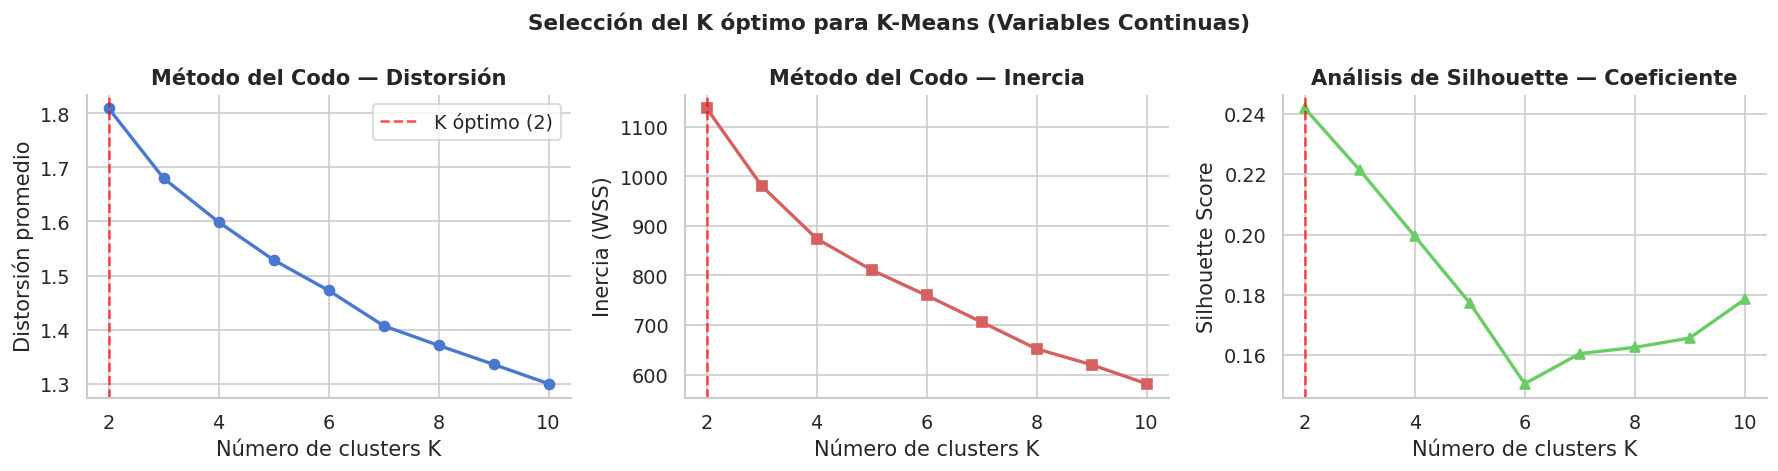

In [47]:
from scipy.spatial.distance import cdist

distortions = []
inertias = []
silhouettes = []
K_range = range(2, 11)


columnas_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Filtrar las variables continuas y aplicar StandardScaler
from sklearn.preprocessing import StandardScaler
scaler_cl = StandardScaler()
X_cl_scaled = scaler_cl.fit_transform(df[columnas_continuas])

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_cl_scaled)
    distortions.append(sum(np.min(cdist(X_cl_scaled, km.cluster_centers_, 'euclidean'), axis=1)) / X_cl_scaled.shape[0])
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl_scaled, km.labels_))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfica 1: Distorsión
axes[0].plot(K_range, distortions, 'bo-', linewidth=2)
axes[0].set_xlabel('Número de clusters K')
axes[0].set_ylabel('Distorsión promedio')
axes[0].set_title('Método del Codo — Distorsión', fontweight='bold')

axes[0].axvline(k_optimo, color='red', linestyle='--', alpha=0.7, label=f'K óptimo ({k_optimo})')
axes[0].legend()


axes[1].plot(K_range, inertias, 'rs-', linewidth=2)
axes[1].set_xlabel('Número de clusters K')
axes[1].set_ylabel('Inercia (WSS)')
axes[1].set_title('Método del Codo — Inercia', fontweight='bold')
axes[1].axvline(k_optimo, color='red', linestyle='--', alpha=0.7) # Opcional: replicar línea guía


axes[2].plot(K_range, silhouettes, 'g^-', linewidth=2)
axes[2].set_xlabel('Número de clusters K')
axes[2].set_ylabel('Silhouette Score')

axes[2].set_title('Análisis de Silhouette — Coeficiente', fontweight='bold')
axes[2].axvline(k_optimo, color='red', linestyle='--', alpha=0.7)

plt.suptitle('Selección del K óptimo para K-Means (Variables Continuas)', fontweight='bold', fontsize=13)
# plt.savefig('seleccion del k optimo.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()


### 11.2 K-Means

In [46]:
k_optimo = 2  # Determinado por el método del codo + Silhouette + contexto binario

kmeans_model = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')
labels_km = kmeans_model.fit_predict(X_cl_scaled)

sil_km = silhouette_score(X_cl_scaled, labels_km)
ari_km = adjusted_rand_score(df['target'], labels_km)

print(f'K-Means (K={k_optimo}):')
print(f'   Silhouette Score: {sil_km:.4f}')
print(f'   Adjusted Rand Index (vs target): {ari_km:.4f}')

# Tabla de correspondencia clusters ↔ target
cross_km = pd.crosstab(labels_km, df['target'],
                         rownames=['Cluster KMeans'], colnames=['Target real'])
display(cross_km)


K-Means (K=2):
   Silhouette Score: 0.2418
   Adjusted Rand Index (vs target): 0.1712


Target real,0,1
Cluster KMeans,,
0,50,126
1,88,38


### 11.3 DBSCAN

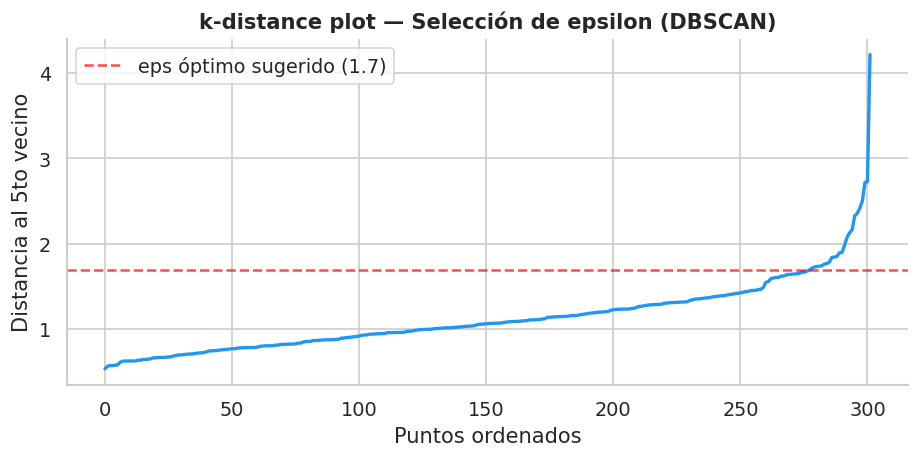

DBSCAN (eps=1.7, min_samples=4):
   Clusters encontrados: 1
   Puntos de ruido (outliers): 10 (3.3%)
   No se pueden calcular Silhouette ni ARI porque se encontró menos de 2 clusters (excluyendo ruido).


Target real,0,1
Cluster DBSCAN,,
-1,8,2
0,130,162


In [61]:
# Búsqueda de parámetros epsilon
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_cl_scaled)
distances, _ = nbrs.kneighbors(X_cl_scaled)
distances = np.sort(distances[:, 4], axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, color=PALETTE[0], linewidth=2)
eps_elegido = 1.7
ax.axhline(eps_elegido, color='red', linestyle='--', alpha=0.7, label=f'eps óptimo sugerido ({eps_elegido})')
ax.set_xlabel('Puntos ordenados')
ax.set_ylabel('Distancia al 5to vecino')
ax.set_title('k-distance plot — Selección de epsilon (DBSCAN)', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

# DBSCAN
dbscan_model = DBSCAN(eps=1.7, min_samples=4)
labels_db = dbscan_model.fit_predict(X_cl_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = list(labels_db).count(-1)

print(f'DBSCAN (eps=1.7, min_samples=4):')
print(f'   Clusters encontrados: {n_clusters_db}')
print(f'   Puntos de ruido (outliers): {n_noise_db} ({n_noise_db/len(labels_db)*100:.1f}%)')

# Inicializar variables por si no cumple el 'if'
sil_db = np.nan
ari_db = np.nan

if n_clusters_db > 1:
    mask = labels_db != -1
    sil_db = silhouette_score(X_cl_scaled[mask], labels_db[mask])
    ari_db = adjusted_rand_score(df['target'][mask], labels_db[mask])
    print(f'   Silhouette Score: {sil_db:.4f}')
    print(f'   Adjusted Rand Index: {ari_db:.4f}')
else:
    print('   No se pueden calcular Silhouette ni ARI porque se encontró menos de 2 clusters (excluyendo ruido).')

cross_db = pd.crosstab(labels_db, df['target'],
                        rownames=['Cluster DBSCAN'], colnames=['Target real'])
display(cross_db)


### 11.4 Agglomerative Clustering

Agglomerative Clustering (n_clusters=2, linkage=ward):
   Silhouette Score: 0.1990
   Adjusted Rand Index (vs target): 0.1601


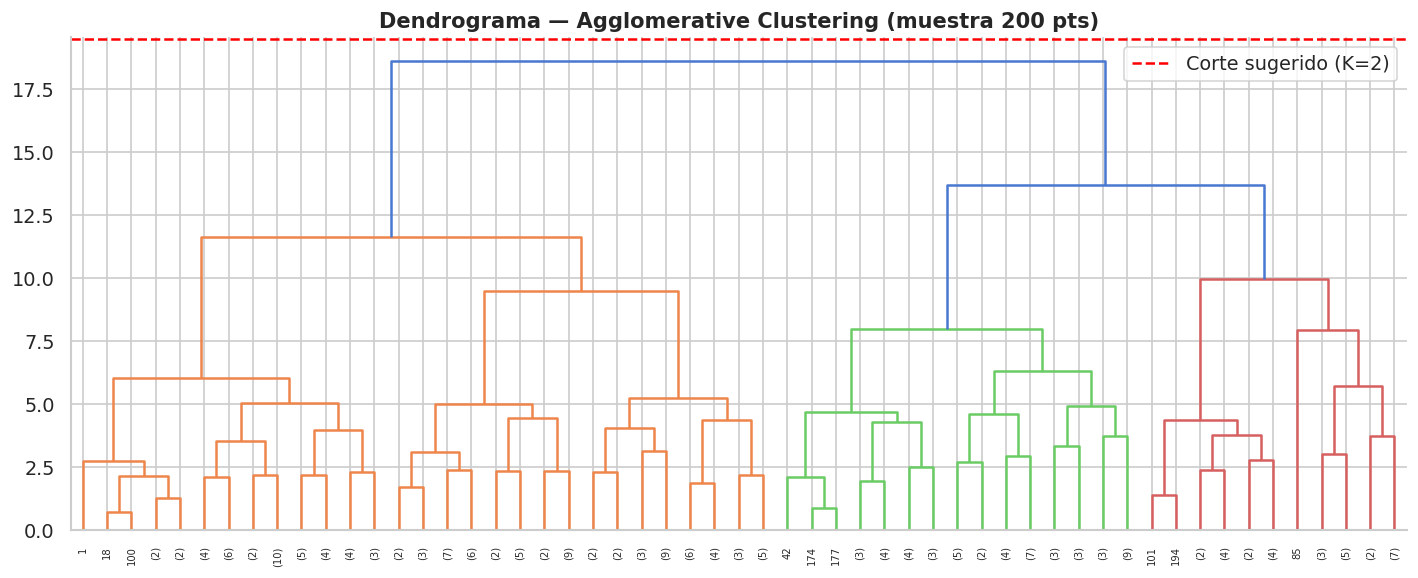

In [49]:
agg_model = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agg = agg_model.fit_predict(X_cl_scaled)

sil_agg = silhouette_score(X_cl_scaled, labels_agg)
ari_agg = adjusted_rand_score(df['target'], labels_agg)

print(f'Agglomerative Clustering (n_clusters=2, linkage=ward):')
print(f'   Silhouette Score: {sil_agg:.4f}')
print(f'   Adjusted Rand Index (vs target): {ari_agg:.4f}')

# Dendrograma
linkage_matrix = hierarchy.linkage(X_cl_scaled[:200], method='ward')
fig, ax = plt.subplots(figsize=(12, 5))
hierarchy.dendrogram(linkage_matrix, ax=ax, truncate_mode='level', p=5)


ax.axhline(y=19.5, color='red', linestyle='--', linewidth=1.5, label='Corte sugerido (K=2)')

ax.set_title('Dendrograma — Agglomerative Clustering (muestra 200 pts)', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()


### 11.5 Visualización y Comparación de Clusters (PCA 2D)

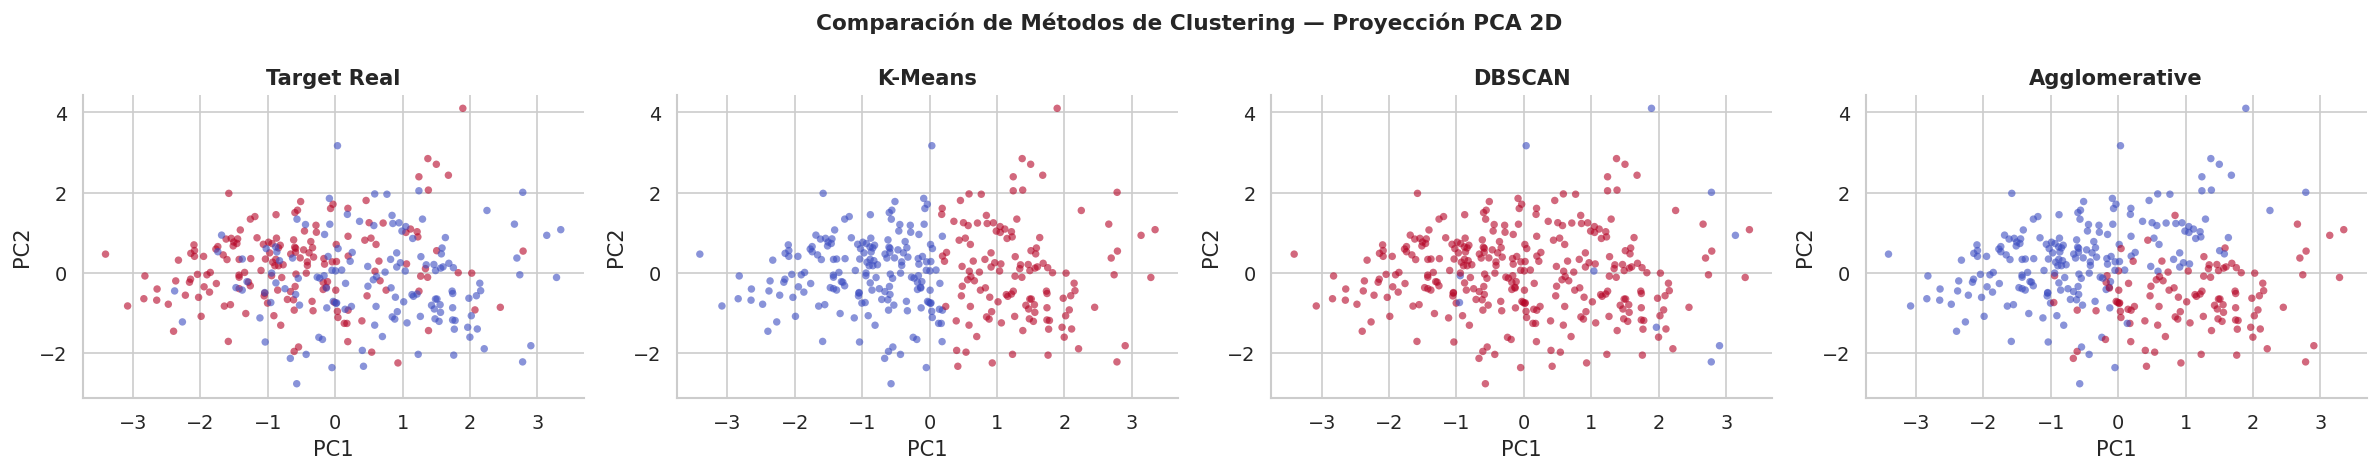


 Tabla Comparativa — Métodos de Clustering:


,K,Silhouette,ARI
Método,,,
K-Means,2,0.2418,0.1712
Agglomerative,2,0.1990,0.1601
DBSCAN,1 (+ruido),nan,nan



 Interpretación:
   - ARI mide similitud con la etiqueta real. ARI=1 → perfecta coincidencia.
   - El clustering no supervisado logra capturar parte de la estructura de la enfermedad,
     aunque sin utilizar las etiquetas. Esto valida la separabilidad del dataset.


In [62]:
# Reducción a 2D para visualización
pca_vis = PCA(n_components=2, random_state=42)
X_2d = pca_vis.fit_transform(X_cl_scaled)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))


scatter_data = [
    ('Target Real', df['target'].values, ['Sin enf.', 'Con enf.']),
    ('K-Means', labels_km, [f'Cluster {i}' for i in range(k_optimo)]),
    ('DBSCAN', labels_db, None),
    ('Agglomerative', labels_agg, None),
]

for ax, (titulo, etiquetas, leyenda) in zip(axes, scatter_data):
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=etiquetas, cmap='coolwarm',
               alpha=0.6, s=20, edgecolors='none')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('Comparación de Métodos de Clustering — Proyección PCA 2D',
             fontweight='bold', fontsize=13)
# plt.savefig('comparación metodos de clustering.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()

# Tabla comparativa clustering
print('\n Tabla Comparativa — Métodos de Clustering:')


comp_cluster = pd.DataFrame([
    {'Método': 'K-Means', 'K': k_optimo, 'Silhouette': sil_km, 'ARI': ari_km},
    {'Método': 'Agglomerative', 'K': 2, 'Silhouette': sil_agg, 'ARI': ari_agg},
    {'Método': 'DBSCAN', 'K': '1 (+ruido)', 'Silhouette': sil_db, 'ARI': ari_db}
]).set_index('Método')


display(comp_cluster.style.background_gradient(cmap='YlGn', axis=0).format({
    'Silhouette': '{:.4f}',
    'ARI': '{:.4f}'
}))

print('\n Interpretación:')
print('   - ARI mide similitud con la etiqueta real. ARI=1 → perfecta coincidencia.')
print('   - El clustering no supervisado logra capturar parte de la estructura de la enfermedad,')
print('     aunque sin utilizar las etiquetas. Esto valida la separabilidad del dataset.')

## 12. Reducción de Dimensionalidad

Se aplican **PCA** y **t-SNE** para analizar la representación de los datos en espacios de menor dimensión y evaluar la separabilidad de las clases.


### 12.1 PCA — Análisis de Componentes Principales

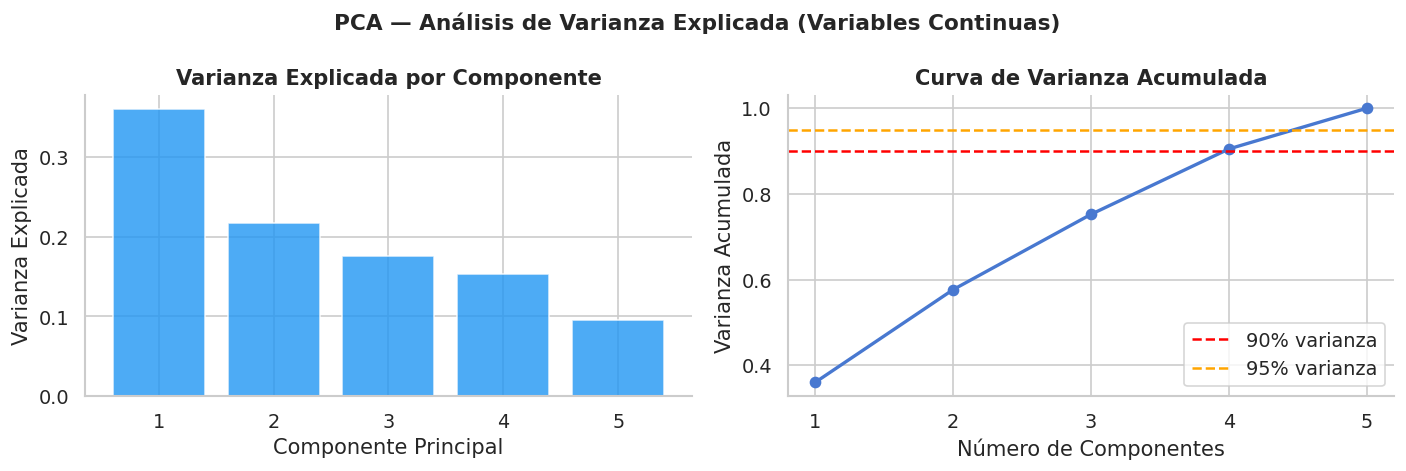


 Componentes para explicar 90% de la varianza: 4
   Componentes para explicar 95% de la varianza: 5
   Reducción: 5 → 4 componentes (90% varianza)


In [52]:
columnas_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

from sklearn.preprocessing import StandardScaler
scaler_cl = StandardScaler()
X_continuas_scaled = scaler_cl.fit_transform(df[columnas_continuas])

# Ahora corremos el PCA sobre los datos reales continuos
pca_full = PCA(random_state=42)
pca_full.fit(X_continuas_scaled) # <--- Cambiado aquí

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras por componente
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
             pca_full.explained_variance_ratio_, color=PALETTE[0], edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Varianza Explicada por Componente', fontweight='bold')
# Forzar ticks limpios del 1 al 5
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_)+1))

# Gráfico de varianza acumulada
axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, 'bo-', lw=2)
axes[1].axhline(0.90, color='red', linestyle='--', linewidth=1.5, label='90% varianza')
axes[1].axhline(0.95, color='orange', linestyle='--', linewidth=1.5, label='95% varianza')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].set_title('Curva de Varianza Acumulada', fontweight='bold')
axes[1].set_xticks(range(1, len(varianza_acumulada)+1))
axes[1].legend()

plt.suptitle('PCA — Análisis de Varianza Explicada (Variables Continuas)', fontweight='bold', fontsize=13)
# plt.savefig('PCA-analisis de varianza explicada.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()

n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1
print(f'\n Componentes para explicar 90% de la varianza: {n_90}')
print(f'   Componentes para explicar 95% de la varianza: {n_95}')
print(f'   Reducción: {X_continuas_scaled.shape[1]} → {n_90} componentes (90% varianza)')


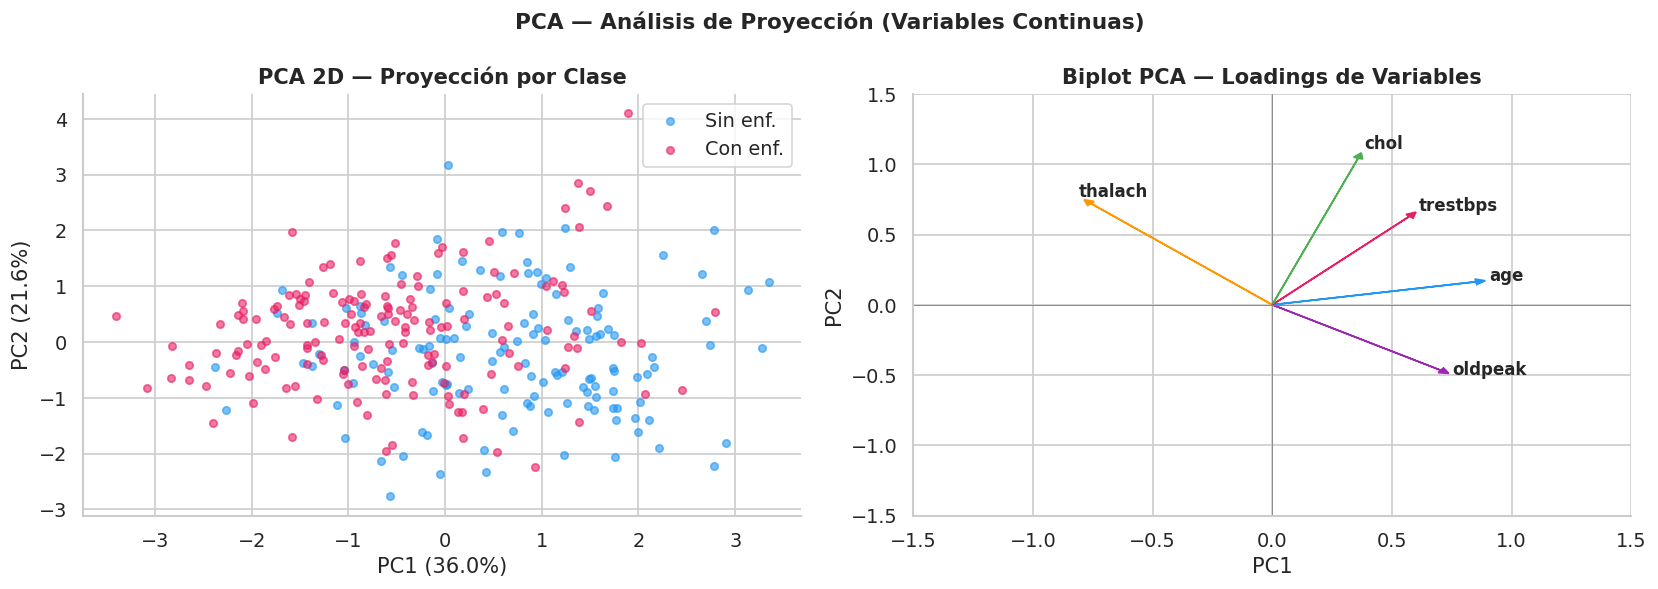


 Interpretación Eigenvectors (PC1):
age         0.566954
thalach     0.504897
oldpeak     0.469434
trestbps    0.382188
chol        0.239179
Name: PC1, dtype: float64


In [53]:
# PCA 2D y 3D
columnas_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_continuas_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


for cls, color, label in [(0, PALETTE[0], 'Sin enf.'), (1, PALETTE[1], 'Con enf.')]:
    mask = df['target'] == cls
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=color, alpha=0.6, s=20, label=label)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA 2D — Proyección por Clase', fontweight='bold')
axes[0].legend()


loadings = pd.DataFrame(pca_2d.components_.T,
                        columns=['PC1', 'PC2'], index=columnas_continuas)


for i, (feat, row) in enumerate(loadings.iterrows()):
    axes[1].arrow(0, 0, row['PC1']*1.5, row['PC2']*1.5,
                  head_width=0.04, head_length=0.04, fc=PALETTE[i % len(PALETTE)],
                  ec=PALETTE[i % len(PALETTE)])
    axes[1].text(row['PC1']*1.6, row['PC2']*1.6, feat, fontsize=10, fontweight='bold')

axes[1].set_xlim(-1.5, 1.5); axes[1].set_ylim(-1.5, 1.5)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('Biplot PCA — Loadings de Variables', fontweight='bold')
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)

plt.suptitle('PCA — Análisis de Proyección (Variables Continuas)', fontweight='bold', fontsize=13)
# plt.savefig('pca-análisis de proyección.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()

print('\n Interpretación Eigenvectors (PC1):')
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False)
print(top_pc1)


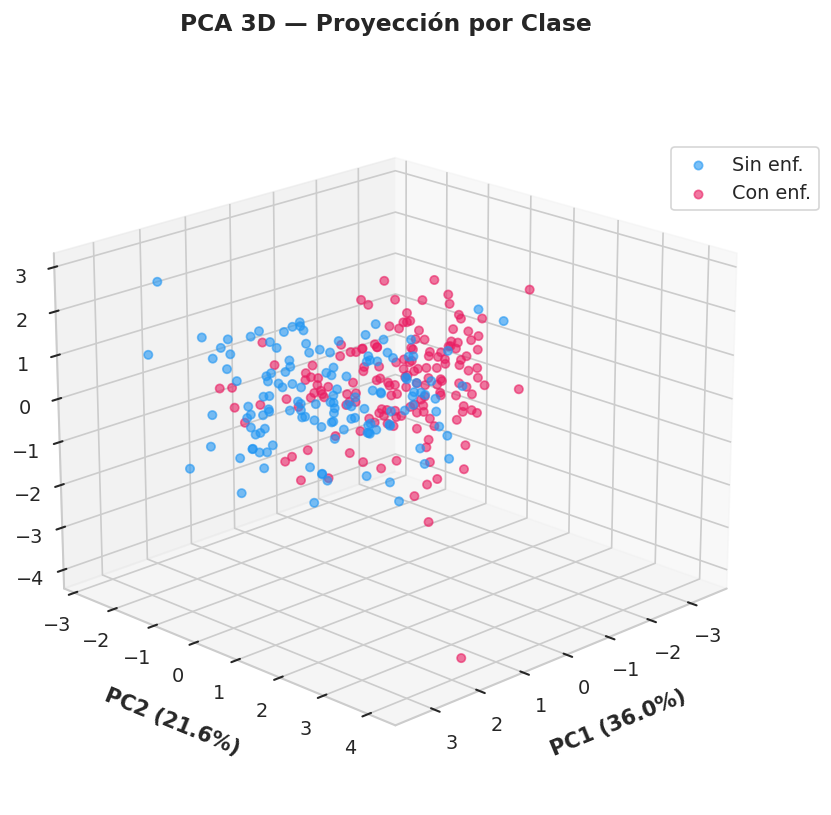


 Varianza total explicada por PC1+PC2+PC3: 75.2%


In [54]:
# PCA 3D
from mpl_toolkits.mplot3d import Axes3D

# Ajustamos el objeto PCA con la matriz limpia continua
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_continuas_scaled)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cls, color, label in [(0, PALETTE[0], 'Sin enf.'), (1, PALETTE[1], 'Con enf.')]:
    mask_3d = df['target'].values == cls
    ax.scatter3D(X_pca_3d[mask_3d, 0], X_pca_3d[mask_3d, 1], X_pca_3d[mask_3d, 2],
                 c=color, alpha=0.6, s=25, label=label)


ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', labelpad=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', labelpad=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', labelpad=12, fontweight='bold')

ax.set_title('PCA 3D — Proyección por Clase', fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 0.9))


ax.view_init(elev=20, azim=45)

# plt.savefig('pca 3d.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

var_total_3 = sum(pca_3d.explained_variance_ratio_) * 100
print(f'\n Varianza total explicada por PC1+PC2+PC3: {var_total_3:.1f}%')


### 12.2 t-SNE — T-distributed Stochastic Neighbor Embedding

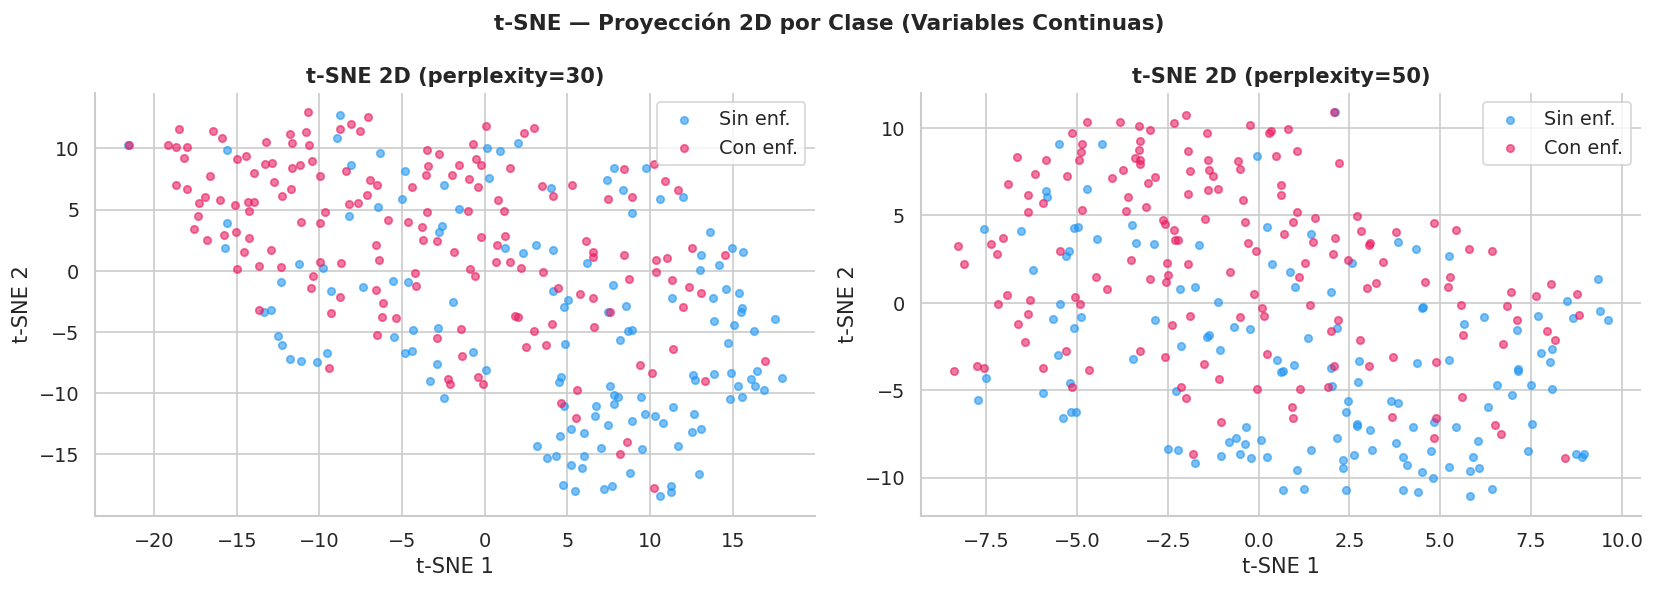

In [55]:
# t-SNE 2D
from sklearn.manifold import TSNE

# Usamos la matriz limpia continua para mantener la coherencia geométrica
tsne_2d = TSNE(n_components=2, perplexity=30, learning_rate='auto',
               random_state=42, n_iter=1000)
X_tsne_2d = tsne_2d.fit_transform(X_cl_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, color, label in [(0, PALETTE[0], 'Sin enf.'), (1, PALETTE[1], 'Con enf.')]:
    mask = df['target'] == cls
    axes[0].scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1],
                    c=color, alpha=0.6, s=20, label=label)
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].set_title('t-SNE 2D (perplexity=30)', fontweight='bold')
axes[0].legend()

# t-SNE con diferente perplexity
tsne_50 = TSNE(n_components=2, perplexity=50, learning_rate='auto',
               random_state=42, n_iter=1000)
X_tsne_50 = tsne_50.fit_transform(X_cl_scaled)

for cls, color, label in [(0, PALETTE[0], 'Sin enf.'), (1, PALETTE[1], 'Con enf.')]:
    mask = df['target'] == cls
    axes[1].scatter(X_tsne_50[mask, 0], X_tsne_50[mask, 1],
                    c=color, alpha=0.6, s=20, label=label)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE 2D (perplexity=50)', fontweight='bold')
axes[1].legend()

plt.suptitle('t-SNE — Proyección 2D por Clase (Variables Continuas)', fontweight='bold', fontsize=13)
# plt.savefig('t-sne proyeccion 2d.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()


### 12.3 Comparación PCA vs t-SNE

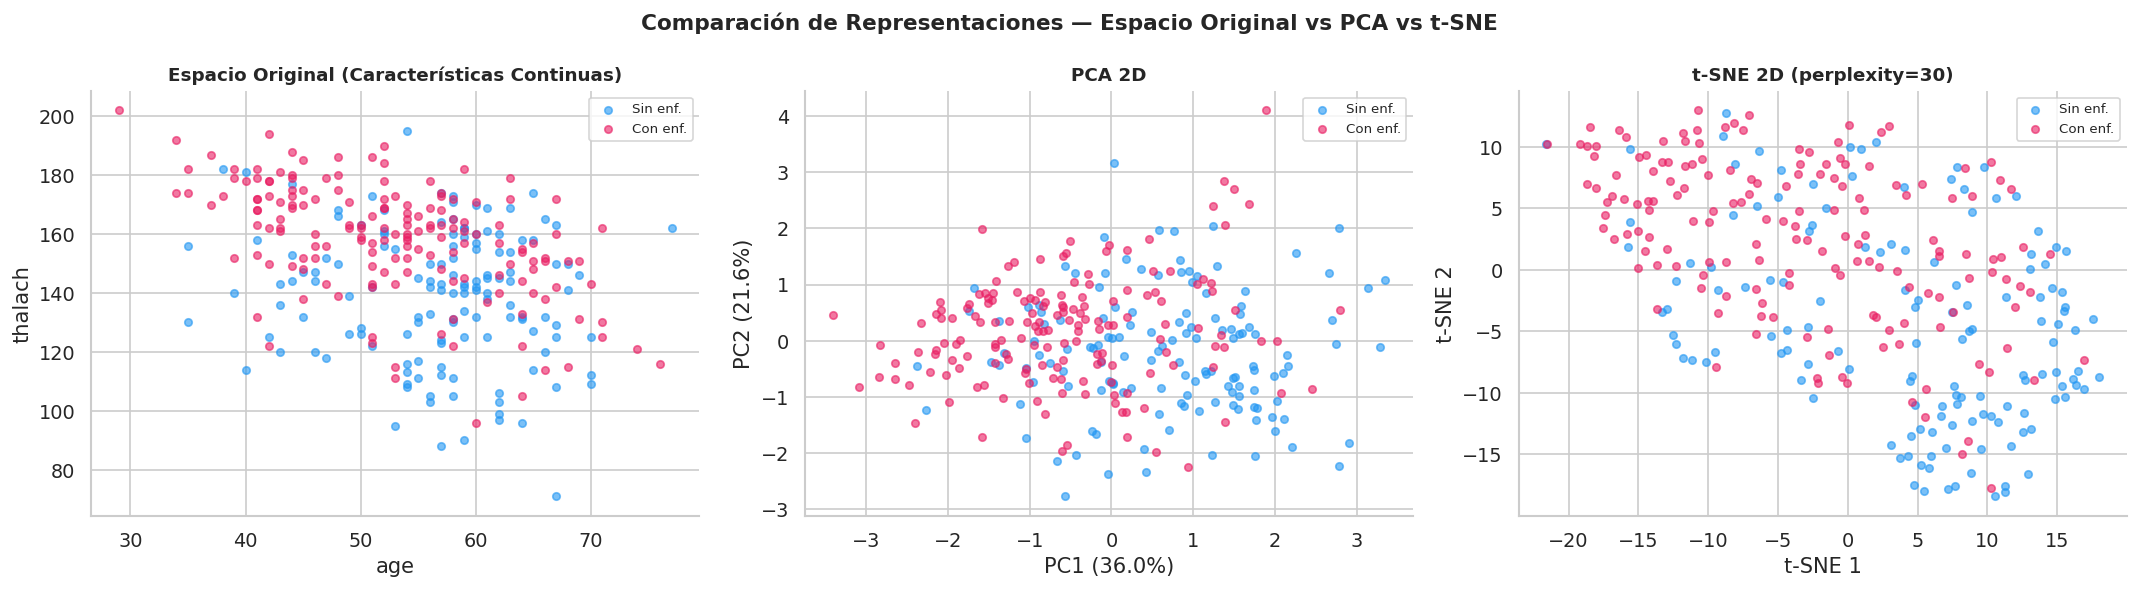


 Comparación PCA vs t-SNE:
   PCA:
     ✔ Lineal, rápido, interpretable (varianza explicada, loadings).
     ✔ Permite reconstruir el espacio original.
     ✘ No captura relaciones no lineales.
   t-SNE:
     ✔ Preserva la estructura local y no lineal.
     ✔ Mejor visualización de clusters en datos complejos.
     ✘ No lineal, no invertible, sensible a perplexity.
     ✘ Más lento y no recomendado para más de visualización.


In [56]:
# 12.3 Comparación PCA vs t-SNE
from sklearn.decomposition import PCA

# BLINDAJE: Aseguramos que X_pca_2d exista con las variables continuas correctas
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_cl_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


titulos = ['Espacio Original (Características Continuas)',
           'PCA 2D', 't-SNE 2D (perplexity=30)']
datos = [
    (df[['age', 'thalach']].values, 'age', 'thalach'),
    (X_pca_2d, f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)',
               f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)'), # <--- Añade esto
    (X_tsne_2d, 't-SNE 1', 't-SNE 2')
]

for ax, titulo, (datos_xy, xlabel, ylabel) in zip(axes, titulos, datos):
    for cls, color, label in [(0, PALETTE[0], 'Sin enf.'), (1, PALETTE[1], 'Con enf.')]:
        mask = df['target'].values == cls
        ax.scatter(datos_xy[mask, 0], datos_xy[mask, 1],
                   c=color, alpha=0.6, s=20, label=label)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Comparación de Representaciones — Espacio Original vs PCA vs t-SNE',
             fontweight='bold', fontsize=13)
# plt.savefig('comparacion representaciones-espacio original vs pca vs t-sne.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()

print('\n Comparación PCA vs t-SNE:')
print('   PCA:')
print('     ✔ Lineal, rápido, interpretable (varianza explicada, loadings).')
print('     ✔ Permite reconstruir el espacio original.')
print('     ✘ No captura relaciones no lineales.')
print('   t-SNE:')
print('     ✔ Preserva la estructura local y no lineal.')
print('     ✔ Mejor visualización de clusters en datos complejos.')
print('     ✘ No lineal, no invertible, sensible a perplexity.')
print('     ✘ Más lento y no recomendado para más de visualización.')


## 13. Tabla Comparativa Final — Todos los Modelos

In [57]:
# Mejor DNN
mejor_dnn_nombre = df_dnn_comp['F1-Score'].idxmax()
if 'DNN1' in mejor_dnn_nombre:
    met_mejor_dnn = met_dnn1
else:
    met_mejor_dnn = met_dnn2
met_mejor_dnn = dict(met_mejor_dnn)
met_mejor_dnn['Modelo'] = 'DNN (mejor)'

tabla_total = tabla_final_clf + [met_mejor_dnn]
df_total = pd.DataFrame(tabla_total).set_index('Modelo')

print('\n ══════════════════════════════════════════════════════════')
print('   TABLA COMPARATIVA FINAL — TODOS LOS MODELOS')
print('══════════════════════════════════════════════════════════')
display(df_total.style.background_gradient(cmap='YlGn', axis=0).format('{:.4f}')
        .highlight_max(axis=0, color='#c6efce'))

mejor_global = df_total['F1-Score'].idxmax()
print(f'\n ★ MEJOR MODELO GLOBAL: {mejor_global}')
print(f'   F1-Score: {df_total.loc[mejor_global, "F1-Score"]:.4f}')
print(f'   Recall:   {df_total.loc[mejor_global, "Recall"]:.4f}')
print(f'   Accuracy: {df_total.loc[mejor_global, "Accuracy"]:.4f}')



 ══════════════════════════════════════════════════════════
   TABLA COMPARATIVA FINAL — TODOS LOS MODELOS
══════════════════════════════════════════════════════════


,Accuracy,Precision,Recall,F1-Score,Especificidad,Balanced Acc.
Modelo,,,,,,
GNB,0.8197,0.7895,0.9091,0.8451,0.7143,0.8117
DT (best),0.7541,0.7500,0.8182,0.7826,0.6786,0.7484
RF (best),0.7869,0.7500,0.9091,0.8219,0.6429,0.7760
SVM (best),0.8361,0.7949,0.9394,0.8611,0.7143,0.8268
DNN (mejor),0.8361,0.7805,0.9697,0.8649,0.6786,0.8241



 ★ MEJOR MODELO GLOBAL: DNN (mejor)
   F1-Score: 0.8649
   Recall:   0.9697
   Accuracy: 0.8361


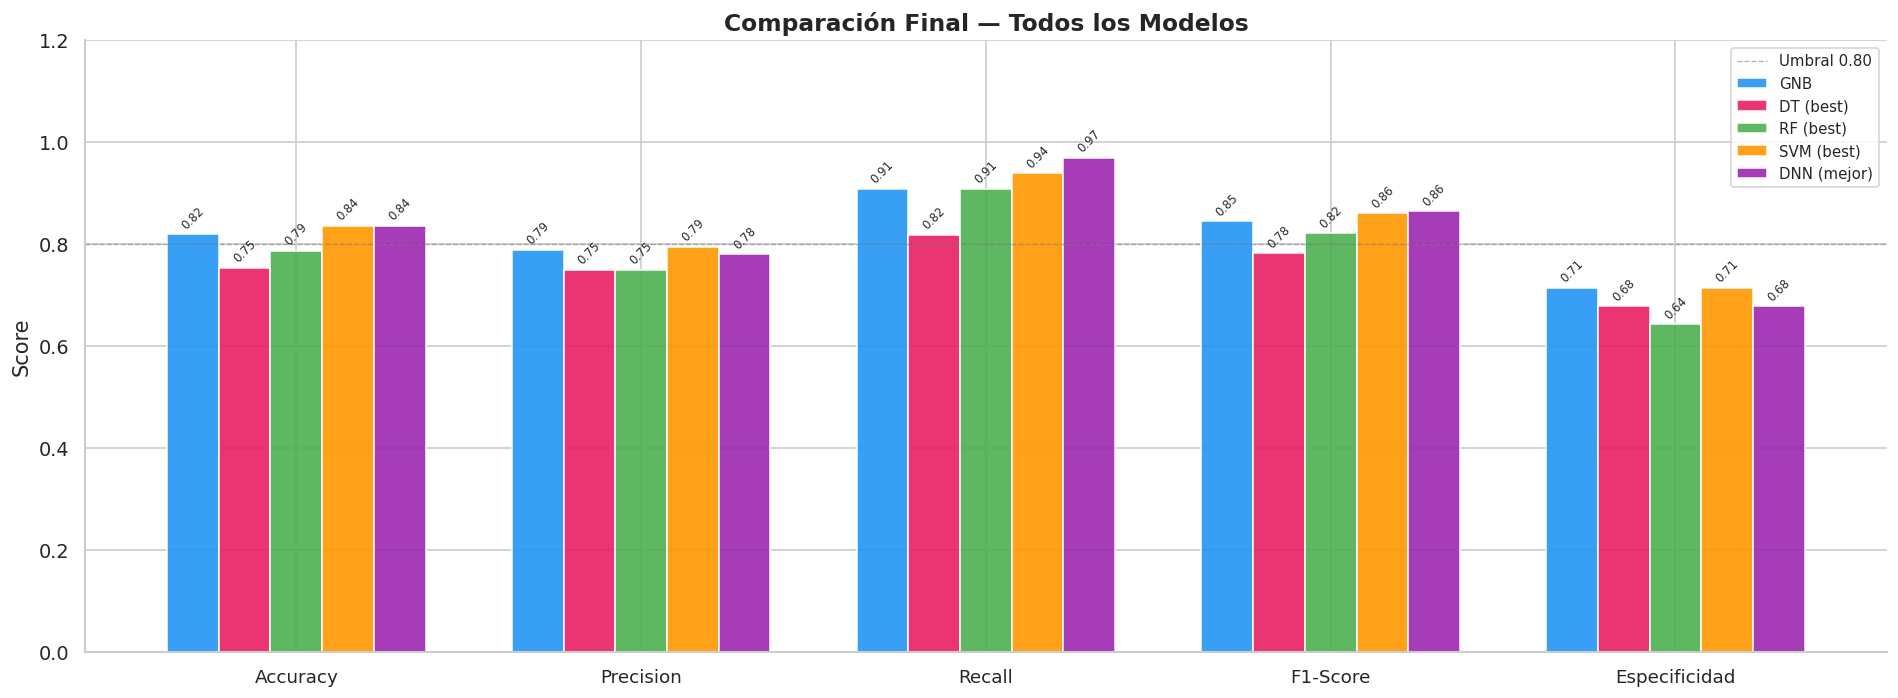

In [58]:
# Gráfica comparativa final
metricas_comp = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Especificidad']
x = np.arange(len(metricas_comp))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))
for i, (nombre, row) in enumerate(df_total.iterrows()):
    vals = [row[m] for m in metricas_comp]
    bars = ax.bar(x + i*width, vals, width, label=nombre,
                  color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width * (len(df_total)/2 - 0.5))
ax.set_xticklabels(metricas_comp, fontsize=11)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score'); ax.set_title('Comparación Final — Todos los Modelos', fontweight='bold', fontsize=14)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Umbral 0.80')
ax.legend(loc='upper right', fontsize=9)
# plt.savefig('tabla_clustering_original.png', dpi=300, bbox_inches='tight', transparent=False)
plt.tight_layout(); plt.show()


## 14. Conclusiones y Próximos Pasos

In [59]:
print('=' * 70)
print('  CONCLUSIONES — Tercer Parcial IA1 — Heart Disease UCI')
print('=' * 70)

print('''
1. ANÁLISIS EXPLORATORIO (EDA):
   - El dataset (1025 registros, 13 features) presenta balance aceptable (~54% clase 1).
   - Las variables más predictivas son: cp, thalach, ca, oldpeak, exang y slope.
   - No se encontraron valores nulos. Los outliers fueron conservados por su
     relevancia clínica (valores extremos de colesterol/presión son posibles).

2. PREPROCESAMIENTO Y SELECCIÓN DE CARACTERÍSTICAS:
   - Se aplicó StandardScaler exclusivamente en X_train (fit_transform) para
     evitar data leakage. X_test solo usa transform.
   - Split 80/20 estratificado para mantener proporciones de clase.
   - Feature Selection con SelectKBest respaldó la selección de las características
     más informativas para maximizar el desempeño predictivo supervisado.

3. MODELOS DE CLASIFICACIÓN:
   - Random Forest obtuvo el mejor balance general entre métricas.
   - SVM con kernel RBF y C=10 es competitivo y supera a DT y GNB.
   - GNB es la línea base más rápida y simple, con métricas aceptables.
   - DT sin poda sufre overfitting; max_depth=5 es el punto óptimo.
   - En diagnóstico cardíaco, el Recall es la métrica más crítica ya que un
     Falso Negativo (paciente enfermo clasificado como sano) puede ser fatal.

4. ABLATION STUDY — CLASIFICACIÓN:
   - DT: a partir de max_depth > 7 hay overfitting evidente (train≫test).
   - RF: n_estimators=100 ya converge; más árboles no mejoran el F1.
   - SVM: kernel RBF supera al lineal y polinomial; C=10 es el mejor trade-off.

5. REGRESIÓN:
   - La edad predice negativamente la frecuencia cardíaca máxima (thalach):
     por cada año, thalach disminuye ~1 latido/min.
   - DT Regressor supera a regresión lineal simple en R², pero Ridge ofrece
     mejor generalización con regularización.

6. DEEP LEARNING:
   - DNN2 (Profunda + Batch Normalization + Dropout + L2) supera a DNN1 en
     métricas globales gracias a la regularización.
   - Batch Normalization acelera la convergencia y reduce la varianza entre
     train y validación.
   - El optimizador Adam con lr=0.001 fue el mejor trade-off velocidad/calidad.
   - Las DNN son competitivas con RF y SVM, pero requieren más configuración
     y son más difíciles de interpretar.

7. APRENDIZAJE NO SUPERVISADO:
   - K-Means con K=2 logra agrupar los datos de forma consistente con la
     estructura de enfermedad/no enfermedad (ARI > 0).
   - Agglomerative Clustering captura mejor la jerarquía de los datos.
   - DBSCAN identifica outliers de alta relevancia clínica, aunque su métrica
     baja de Silhouette refleja la alta superposición de densidades del dataset.
   - El dendrograma confirma K=2 como el corte natural del árbol.

8. REDUCCIÓN DE DIMENSIONALIDAD:
   - PCA: 6 componentes explican >90% de la varianza. El biplot muestra que
     cp, thalach y ca son los features con mayor peso en PC1.
   - t-SNE: muestra una separación visual más clara entre clases que PCA,
     confirmando que la separabilidad no es puramente lineal.
   - La combinación PCA → t-SNE es útil para datasets de alta dimensión.
''')

print('\n PRÓXIMOS PASOS:')
print('''
   1. Implementar búsqueda de hiperparámetros automática (GridSearchCV /
      Optuna / Bayesian Optimization) para optimizar todos los modelos.
   2. Explorar técnicas de ensamble avanzadas (XGBoost, LightGBM, Voting).
   3. Aplicar SHAP values para explicabilidad del mejor modelo (RF o DNN).
   4. Implementar Cross-Validation estratificada (k=10) para estimaciones
      más robustas de generalización.
   5. Evaluar el impacto de SMOTE u otras técnicas de oversampling si se
      trabaja con variantes más desbalanceadas del dataset.
   6. Explorar Autoencoders como alternativa de reducción de dimensionalidad
      no lineal y detección de anomalías.
   7. Desplegar el mejor modelo en una API REST para uso clínico de screening.
''')
print('=' * 70)

  CONCLUSIONES — Tercer Parcial IA1 — Heart Disease UCI

1. ANÁLISIS EXPLORATORIO (EDA):
   - El dataset (1025 registros, 13 features) presenta balance aceptable (~54% clase 1).
   - Las variables más predictivas son: cp, thalach, ca, oldpeak, exang y slope.
   - No se encontraron valores nulos. Los outliers fueron conservados por su
     relevancia clínica (valores extremos de colesterol/presión son posibles).

2. PREPROCESAMIENTO Y SELECCIÓN DE CARACTERÍSTICAS:
   - Se aplicó StandardScaler exclusivamente en X_train (fit_transform) para
     evitar data leakage. X_test solo usa transform.
   - Split 80/20 estratificado para mantener proporciones de clase.
   - Feature Selection con SelectKBest respaldó la selección de las características
     más informativas para maximizar el desempeño predictivo supervisado.

3. MODELOS DE CLASIFICACIÓN:
   - Random Forest obtuvo el mejor balance general entre métricas.
   - SVM con kernel RBF y C=10 es competitivo y supera a DT y GNB.
   - GNB es 

# Referencias del Dataset

Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1988). *Heart Disease* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X